Classification of mitotic phases in histopathology data
===================================================

Authors : 'Elyesse and Alexandre'

Supervision : 'Thomas and Raphaël'

Mitotic activity is a central indicator of tumor proliferation and prognosis. The most relevant information used today by pathologists is the count of mitotic events in selected regions. Identifying precise counts manually at the level of the entire tissue section is not possible,
as in a single slide there are hundreds of thousands of individual cells. AI solutions to automate the detection and counting process have been proposed, and the CBIO has developed solutions that are currently state-of-the-art (1st and 2nd place in two recent competitions).

However, we believe that more information on cell division could be leveraged by not only identifying and counting dividing cells, but also by dertermining the precise mitotic phase. Such an analysis could point to specific mechanisms of deregulation, potentially linked to clinical outcomes.

In this project, we propose to train Neural Networks to identify mitotic phases in Whole Slide Images.

Setup & configuration
===================================================

In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports
===================================================


In [2]:
# --- 1. Standard & System Imports ---
import os
import random
import time
import copy
from pathlib import Path

# --- 2. Data & Image Manipulation ---
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import seaborn as sns

# --- 3. PyTorch & Torchvision ---
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.transforms import v2, InterpolationMode

# --- 4. Specific Libraries (Histopathology & Explainability) ---
import torchstain          # Color normalization
# from torchcam.methods import SmoothGradCAMpp # For final visualization
# from torchcam.utils import overlay_mask

# --- 5. Sklearn (Metrics) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.manifold import TSNE
from scipy.stats import entropy

# --- 6. Grad-CAM (XAI) ---
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- Graphic Configuration ---
sns.set_theme(style="whitegrid") # For more aesthetic plots
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
from src.config import CONFIG, ROOT_DIR, seed_everything
from src.data_analysis import load_and_analyze_metadata, compare_experts_agreement
from src.dataset import MitosisDataset
from src.utils import get_transforms, prepare_data_loaders, imshow, visualize_model
from src.train import train_model, get_convnext_model
from src.evaluation import evaluate_expert_comparison, evaluate_top2_indulgent, plot_soft_confusion_matrix, evaluate_by_groups, run_full_test_battery
from src.visualization import plot_array, visualize_tsne_dual_expert, visualize_upstream_downstream_comparison, visualize_explanation_simple, visualize_confidence_tsne

seed_everything(42)

In [4]:
df_stats = load_and_analyze_metadata('data/AMI-BR.csv')

Failed to read module file 'c:\Users\elyes\Bash\r_sante\src\evaluation.py' for module 'src.evaluation': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\elyes\Bash\r_sante\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ~~~~~~^^
  File "C:\miniconda\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8d in position 1840: character maps to <undefined>
Failed to read module file 'c:\Users\elyes\Bash\r_sante\src\visualization.py' for module 'src.visualization': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\elyes\Bash\r_sante\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in u

--- DATASET ANALYSIS (3720 cells) ---

[PHASES] Expert 1 / Expert 2 Agreement : 70.65%

[ATYPIA] Vote distribution :
- Consensus (3/3 experts): 412 (11.1%)
- Simple majority (>= 2/3): 832 (22.4%)
- Total disagreement (1 or 2 votes): 812 (21.8%)
- Strictly Normal (0/3 votes): 2496 (67.1%)

[CONFUSIONS] Top 5 most frequent phase disagreements :
expert1_label     expert2_label  
NMF prometaphase  NMF metaphase      244
                  AMF segregation    131
NMF metaphase     AMF segregation    121
NMF prometaphase  NMF ring shape     112
                  AMF other           53
dtype: int64

[CLASSES] Final distribution (based on Expert 1) :
expert1_label
NMF prometaphase          41.048387
NMF metaphase             36.263441
AMF other                  6.854839
NMF anaphase-telophase     6.801075
AMF segregation            4.139785
AMF multipolar             1.908602
AMF bipolar assymetric     1.586022
NMF ring shape             1.397849
Name: proportion, dtype: float64


Comparison of Expert 2 labels (true) vs Expert 1 (predicted for comparison) on 3720 samples of the full dataset :
                        precision    recall  f1-score   support

AMF bipolar assymetric       0.33      0.59      0.43        59
        AMF multipolar       0.72      0.39      0.51        71
             AMF other       0.51      0.47      0.49       255
       AMF segregation       0.25      0.78      0.38       154
NMF anaphase-telophase       0.80      0.66      0.72       253
         NMF metaphase       0.78      0.87      0.83      1349
      NMF prometaphase       0.95      0.62      0.75      1527
        NMF ring shape       0.23      0.65      0.33        52

              accuracy                           0.71      3720
             macro avg       0.57      0.63      0.55      3720
          weighted avg       0.80      0.71      0.73      3720



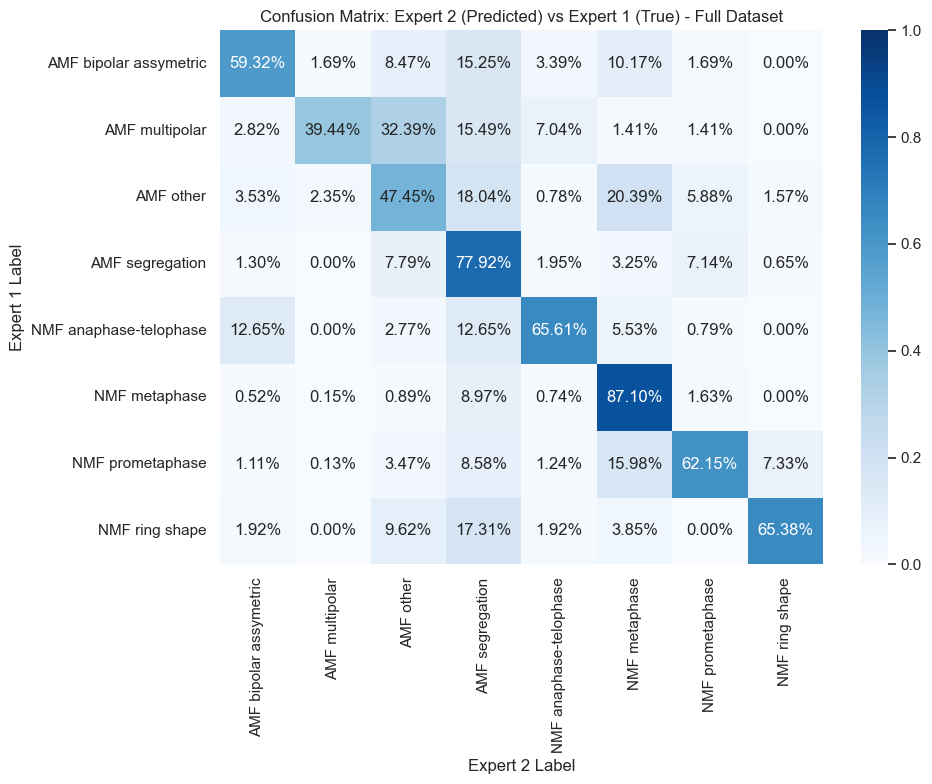

In [5]:
compare_experts_agreement(df_stats)

The dataset we are going to deal with is that of AMI-Br.

Dataset comes with a `AMI-BR.csv` file with annotations which looks like this:

``` {.sh}
,slide,dataset,uid,x,y,expert1_label,expert2_label,expert1_atypical,expert2_atypical,expert3_atypical,majority_atypical
0,002.tiff,MIDOG21,6,4422,216,NMF prometaphase,NMF metaphase,False,False,False,False
1,002.tiff,MIDOG21,7,1867,1583,AMF segregation,AMF segregation,True,True,True,True
```

Let\'s take a single image name and its annotations from the CSV, in
this case row index number 65 for `MIDOG21_194.png` just as an example.


In [9]:
mitosis_frame = pd.read_csv('data/AMI-BR.csv')
class_names = sorted(mitosis_frame['expert1_label'].unique())

n = 65
img_name = f"{mitosis_frame.iloc[n]['dataset']}_{mitosis_frame.iloc[n]['uid']}.png"

print('Image name: {}, expert1_label: {}, expert2_label: {}, expert1_atypical: {}, expert2_atypical: {}, expert3_atypical: {}, majority_atypical: {}'.format(img_name, mitosis_frame.iloc[n]['expert1_label'], mitosis_frame.iloc[n]['expert2_label'], mitosis_frame.iloc[n]['expert1_atypical'], mitosis_frame.iloc[n]['expert2_atypical'], mitosis_frame.iloc[n]['expert3_atypical'], mitosis_frame.iloc[n]['majority_atypical']))

Image name: MIDOG21_194.png, expert1_label: NMF metaphase, expert2_label: NMF metaphase, expert1_atypical: False, expert2_atypical: False, expert3_atypical: False, majority_atypical: False


## Data Strategy: Embracing Disagreement via Soft-Labels

Standard classification assumes one image = one class. In our dataset, this assumption fails for ~30% of the data. To handle this, we construct a dynamic dataset:

* **Consensus Cases (Group A):** Both experts agree.
    * *Target:* One-Hot Vector (e.g., `[0, 1, 0, 0]`).
* **Disagreement Cases (Group B):** Experts disagree.
    * *Target:* Soft Distribution (e.g., `[0.5, 0.5, 0, 0]`).

This prevents the model from being penalized for legitimate biological ambiguity.

 Dataset initialized in [NMF] mode
   -> 2888 images found.
   -> 8 classes : {'AMF bipolar assymetric': 0, 'AMF multipolar': 1, 'AMF other': 2, 'AMF segregation': 3, 'NMF anaphase-telophase': 4, 'NMF metaphase': 5, 'NMF prometaphase': 6, 'NMF ring shape': 7}
0 (128, 128) soft_label: {'NMF metaphase': 0.5, 'NMF prometaphase': 0.5}


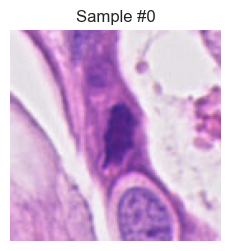

1 (128, 128) soft_label: {'NMF metaphase': 1.0}


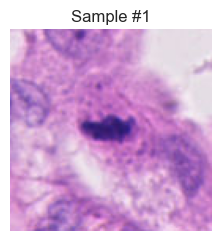

2 (128, 128) soft_label: {'NMF metaphase': 0.5, 'NMF prometaphase': 0.5}


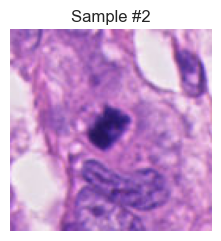

3 (128, 128) soft_label: {'NMF prometaphase': 1.0}


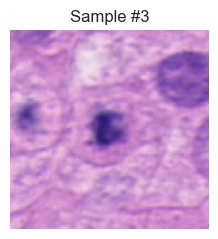

In [8]:
df = df_stats[df_stats['majority_atypical'] == False].copy()
mitosis_dataset = MitosisDataset(df, root_dir=ROOT_DIR, transform=None)

fig = plt.figure()

for i, (image, label) in enumerate(mitosis_dataset):
    # Print only non-zero soft-label entries (for readability)
    probs = label.detach().cpu().numpy() if isinstance(label, torch.Tensor) else np.array(label)
    nz = {mitosis_dataset.classes[j]: float(np.round(probs[j], 4)) for j in range(len(probs)) if probs[j] > 1e-6}
    print(i, image.size, "soft_label:", nz)

    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title('Sample #{}'.format(i))
    ax.axis('off')
    plt.imshow(image)
    plt.pause(0.001)

    if i == 3:
        plt.show()
        break

Load Data
=========

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve is to train a model to classify
**mitotic phases**. We have about 3 720 training images.

In [11]:
# 6. DATALOADER PREPARATION (SPLIT & TRANSFORM)
# Note: We reuse df_stats (loaded in step 3)

dataloaders, (train_df, val_df, test_df), data_transforms = prepare_data_loaders(
    full_df=df_stats,
    config=CONFIG,
    root_dir=ROOT_DIR,
    get_transforms_fn=get_transforms, # Pass the function reference (Dependency Injection)
    dataset_cls=MitosisDataset        # Pass the class reference
)

# Quick check to ensure the loader is populated
print(f"Check Train Loader: {len(dataloaders['train'])} batches")

train_loader = dataloaders['train']
val_loader = dataloaders['val']
test_loader = dataloaders['test']
train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_dataset = test_loader.dataset

--- 🚀 STARTING DATA PREPARATION (NMF) ---
Total images for mode NMF : 2888
⚠️ Classes dropped because too rare : ['AMF segregation', 'AMF other', 'AMF multipolar', 'AMF bipolar assymetric']
Stratification key ready. Unique vectors: 10
Generated splits : Train=2200, Val=275, Test=275
 Dataset initialized in [NMF] mode
   -> 2200 images found.
   -> 4 classes : {'NMF anaphase-telophase': 0, 'NMF metaphase': 1, 'NMF prometaphase': 2, 'NMF ring shape': 3}
 Dataset initialized in [NMF] mode
   -> 275 images found.
   -> 4 classes : {'NMF anaphase-telophase': 0, 'NMF metaphase': 1, 'NMF prometaphase': 2, 'NMF ring shape': 3}
 Dataset initialized in [NMF] mode
   -> 275 images found.
   -> 4 classes : {'NMF anaphase-telophase': 0, 'NMF metaphase': 1, 'NMF prometaphase': 2, 'NMF ring shape': 3}
⚖️ WeightedRandomSampler activated.
✅ DataLoaders ready !
Check Train Loader: 69 batches


c:\Users\elyes\Bash\r_sante\src\utils.py:201: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  weights=torch.from_numpy(sample_weights),


## Exploratory Data Analysis: Visualizing Biological Variability

Before feeding data into the model, we inspect the variability of the samples.
The challenge is twofold:
1.  **Staining Variability:** Differences in color intensity (H&E stain) between scanners.
2.  **Biological Continuum:** Mitosis is a continuous process, not discrete steps.

**Below:** We display a grid of random samples. Note how some "Prophase" cells look very similar to "Interphase" (background cells), illustrating why expert disagreement is common.

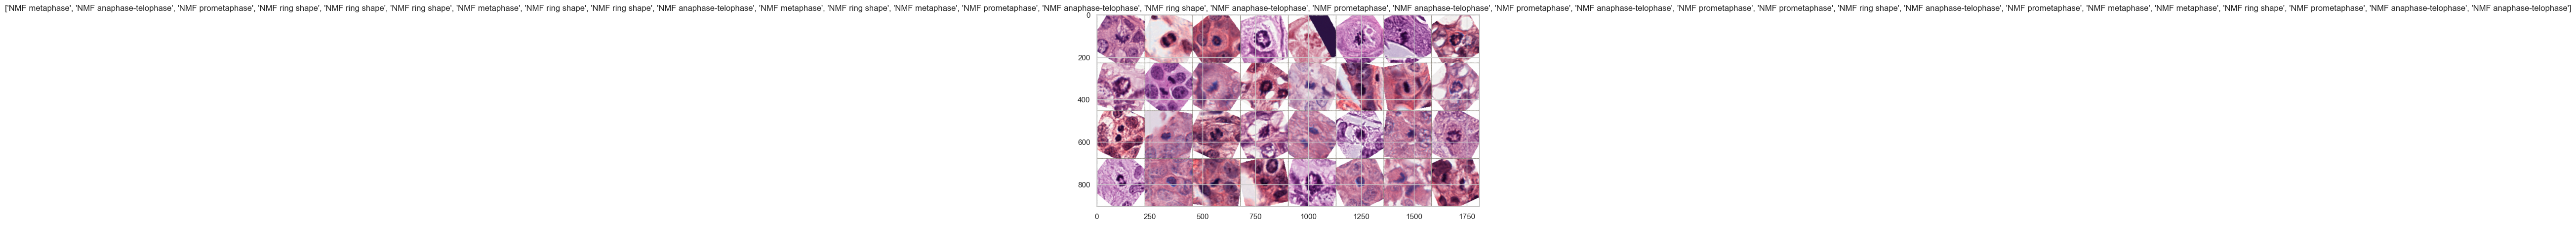

In [12]:
# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

# Convert soft labels (float tensors) to integer class indices for display
# We use argmax to get the most prominent class from the soft label
imshow(out, title=[train_dataset.classes[x.item()] for x in torch.argmax(classes, dim=1)])

## Model Architecture: Why ConvNeXt?

We selected **ConvNeXt-Tiny** as our backbone.
* **Modern Design:** It modernizes standard CNNs (like ResNet) by adopting design choices from Vision Transformers (larger kernels, fewer activation functions).
* **Efficiency:** It offers a better accuracy/speed trade-off than heavy Transformers (ViT) on small medical datasets.
* **Transfer Learning:** We initialize with weights pre-trained on **ImageNet**, allowing the model to leverage learned edge/texture detectors before adapting to histopathology features.

In [13]:
# --- SETUP ---
model = get_convnext_model(num_classes=len(train_dataset.classes), mode=CONFIG['TRAIN'])
model = model.to(CONFIG['DEVICE']) # Ensure 'device' is defined (cuda/cpu)

# --- THE AVOIDED PITFALL ---
# We only pass to the optimizer the parameters that need to be learned
params_to_update = []
for name, param in model.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)

print(f"Number of parameters to train : {len(params_to_update)}")

# The optimizer only works on the filtered list
optimizer = optim.AdamW(params_to_update, lr=CONFIG['LR'], weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

--- Loading convnext_tiny model (Mode: full) ---
-> Entire network is trainable
Number of parameters to train : 182


Train and evaluate
==================

Starting training on cpu for 1 epochs.
--------------------------------------------------
Epoch 1/1
TRAIN Loss: 0.8801 | Bounded Acc: 63.56%
VAL Loss: 0.4647 | Bounded Acc: 80.30%
    -> New champion (Loss: 0.4647) ! Saved as 'best_model.pth'

Training complete in 14m 44s
Best Val Loss: 0.4647


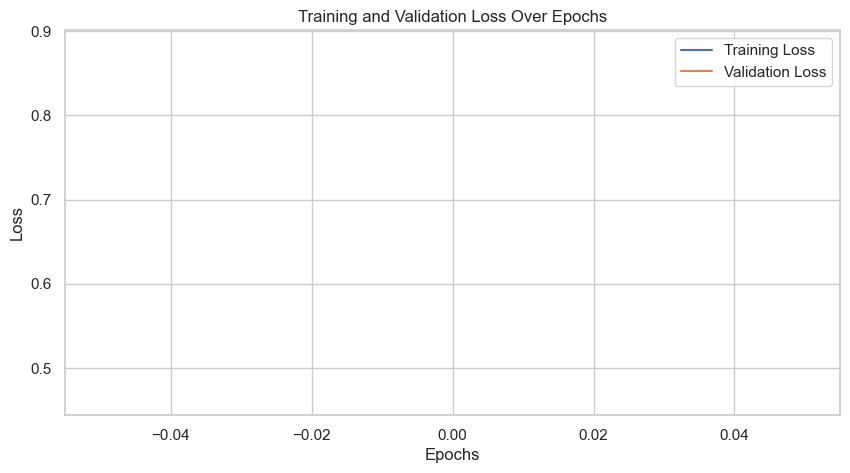

In [14]:
model_ft, train_history_loss, val_history_loss = train_model(model, dataloaders, criterion, optimizer, num_epochs=1)
plt.figure(figsize=(10, 5))
plt.plot(train_history_loss, label='Training Loss')
plt.plot(val_history_loss, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

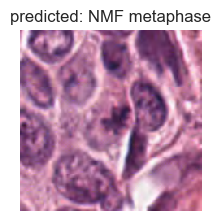

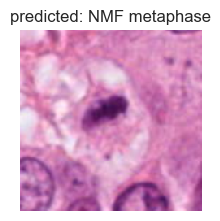

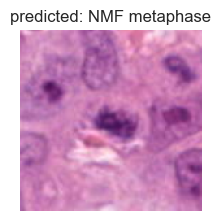

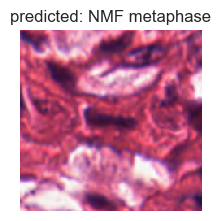

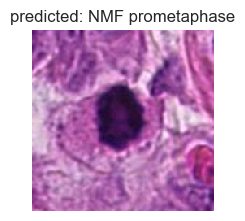

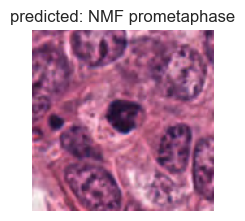

In [39]:
model_ft.load_state_dict(torch.load('best_model.pth', map_location=CONFIG['DEVICE']))
visualize_model(model_ft, dataloaders)

## Confusion Analysis & Human Baseline

We compare the model against both experts individually.
* **Key Insight:** The agreement between Expert 1 and Expert 2 is approximately **70%**.
* **Theoretical Limit:** Our model cannot meaningfully exceed this 70% accuracy against a single expert without overfitting their specific bias.

We also use a **"Top-2 Indulgent"** matrix. If the model's second guess matches the ground truth, it is counted as correct. This reveals whether errors are "near-misses" (e.g., Prophase vs. Prometaphase) or "hallucinations" (e.g., Prophase vs. Telophase).

## The "Human Ceiling" Benchmark
To contextualize the model's performance, we compare three scenarios:
1.  **Model vs. Expert 1**
2.  **Model vs. Expert 2**
3.  **Expert 1 vs. Expert 2 (Inter-rater Agreement)**
* **Insight:** The agreement between the two human experts (approx. 70%) represents the **theoretical upper bound**. A model exceeding this limit would likely be overfitting to a specific annotator's bias rather than learning the general biological features.

Generating model predictions...

🔍 RESULTS vs EXPERT 1
                        precision    recall  f1-score   support

NMF anaphase-telophase       1.00      0.89      0.94        18
         NMF metaphase       0.88      0.95      0.91       119
      NMF prometaphase       0.95      0.86      0.90       134
        NMF ring shape       0.30      0.75      0.43         4

              accuracy                           0.90       275
             macro avg       0.78      0.86      0.80       275
          weighted avg       0.91      0.90      0.90       275


🔍 RESULTS vs EXPERT 2
                        precision    recall  f1-score   support

NMF anaphase-telophase       1.00      0.84      0.91        19
         NMF metaphase       0.97      0.87      0.92       143
      NMF prometaphase       0.79      0.97      0.87        98
        NMF ring shape       0.90      0.60      0.72        15

              accuracy                           0.89       275
             macro av

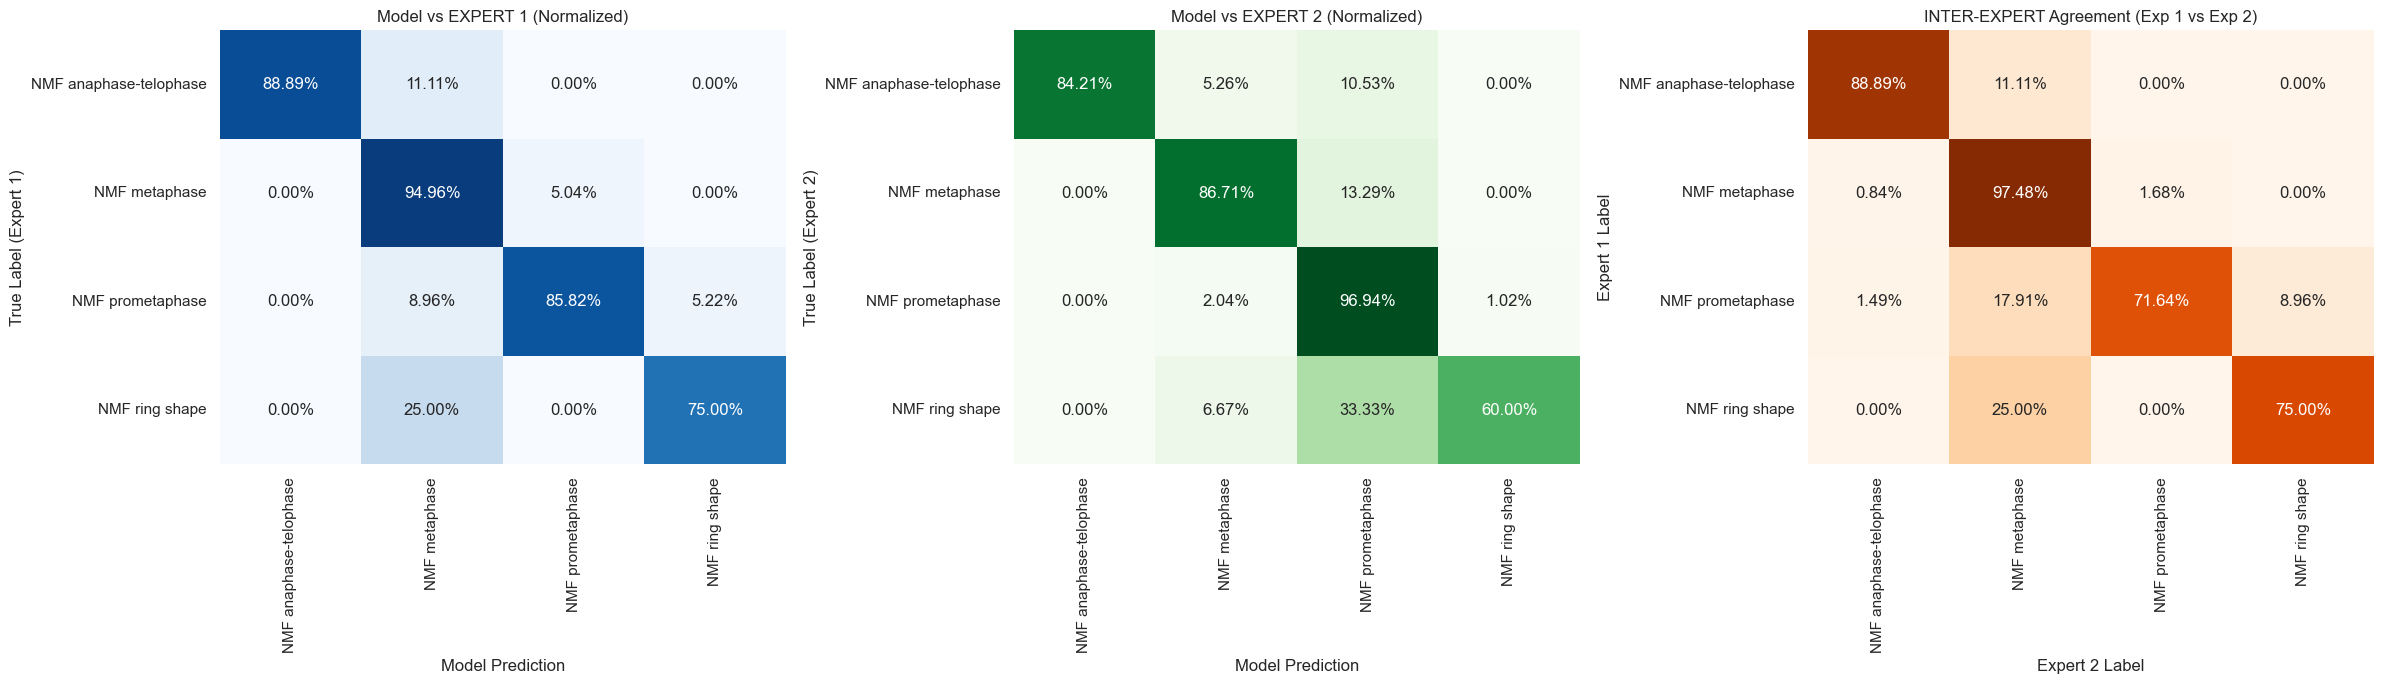

In [41]:
# --- HOW TO USE IT ---
# 1. Load your best trained model
model_ft.load_state_dict(torch.load('best_model.pth', map_location=CONFIG['DEVICE']))

# 2. Run evaluation (Ensure you pass the corresponding DataFrame!)
evaluate_expert_comparison(model_ft, val_loader, val_df, CONFIG['DEVICE'])

## Top-2 "Indulgent" Accuracy
Mitosis is a continuous biological process, not a set of discrete steps. "Errors" often occur at the transition between phases (e.g., Late Prophase vs. Early Prometaphase).
* **Metric:** We consider a prediction correct if the Ground Truth is within the model's **Top-2 probabilities**.
* **Interpretation:** This distinguishes between **"Near-Misses"** (medically acceptable hesitation) and **"Hallucinations"** (confusing distinct phases like Prophase and Telophase).

Generating Top-2 predictions...


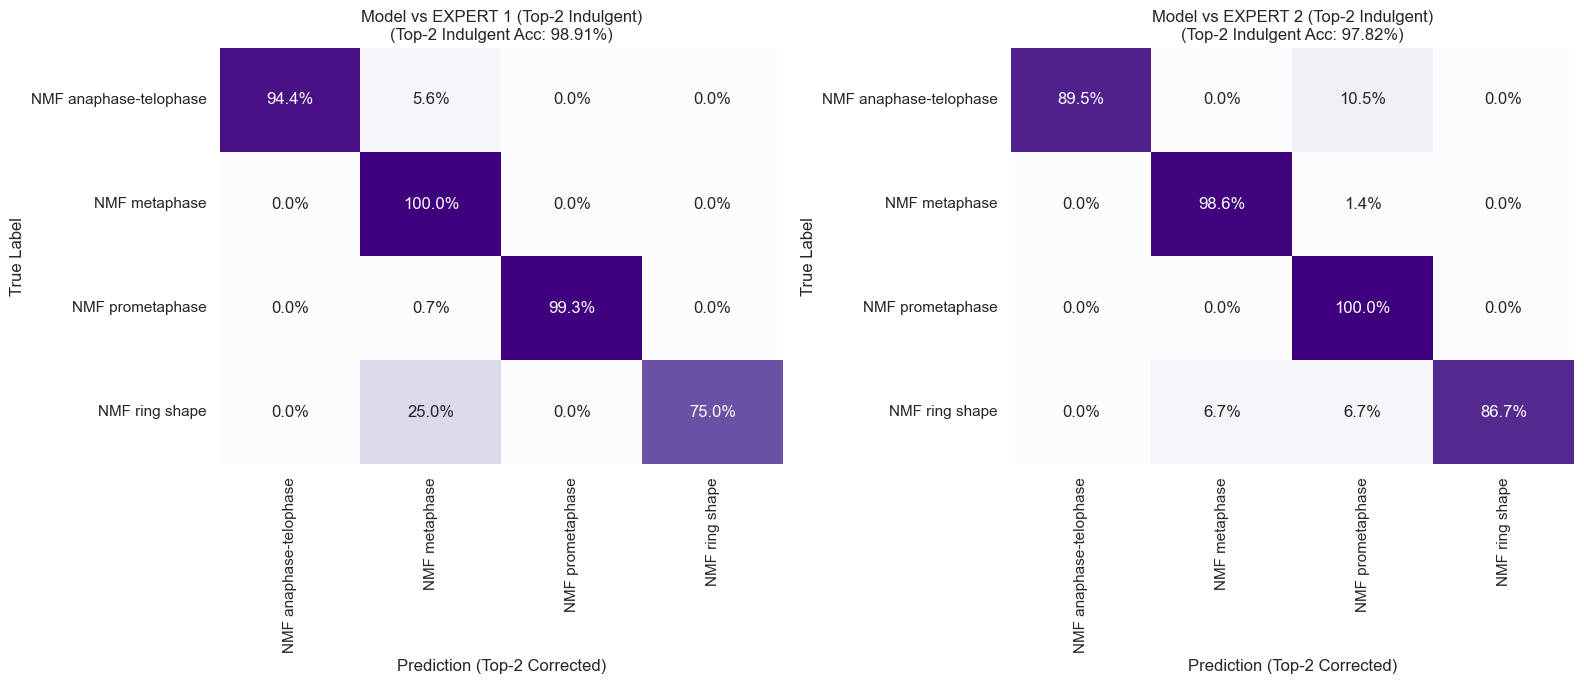

In [42]:
evaluate_top2_indulgent(model_ft, val_loader, val_df, CONFIG['DEVICE'])

# Comprehensive Evaluation & Visualization Pipeline

Since standard accuracy is insufficient for medical data with high inter-observer variability, we designed a **multi-layered evaluation framework**. This pipeline assesses performance, calibration, and interpretability.

In [43]:
plt.rcParams['figure.figsize'] = (8.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Visualization of the encodings by t-SNE

We will first visualize the data.

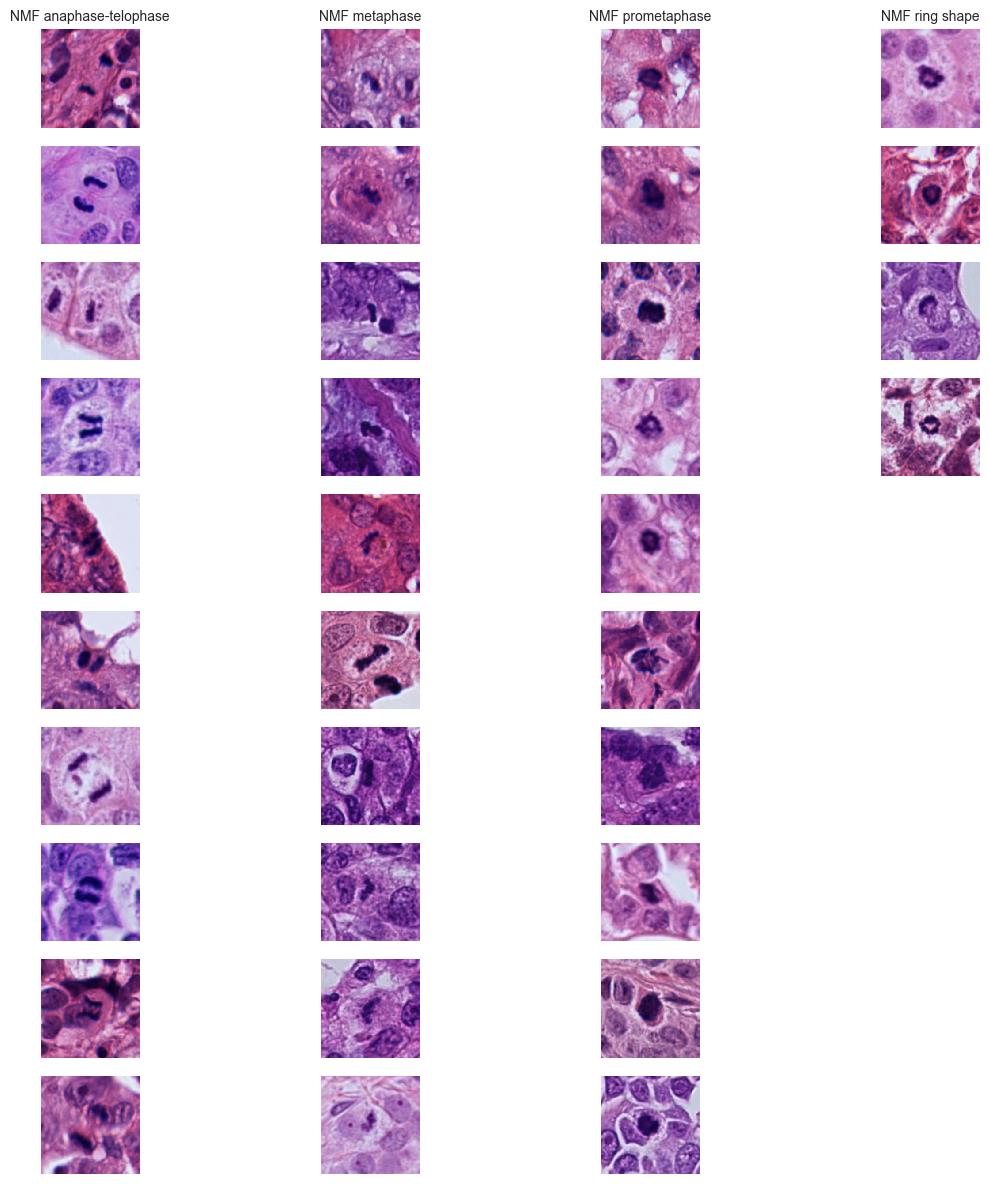

In [44]:
# --- Execution ---
fig = plt.figure(figsize=(12, 12))
# Use train_dataset or val_dataset depending on what you have loaded
plot_array(fig, val_dataset, samples_per_class=10)
plt.tight_layout()
plt.show()

Now, we will extract the features of a layer and visualize the distribution of the encodings with t-SNE.

Extracting features...
Calculating t-SNE on 275 points...


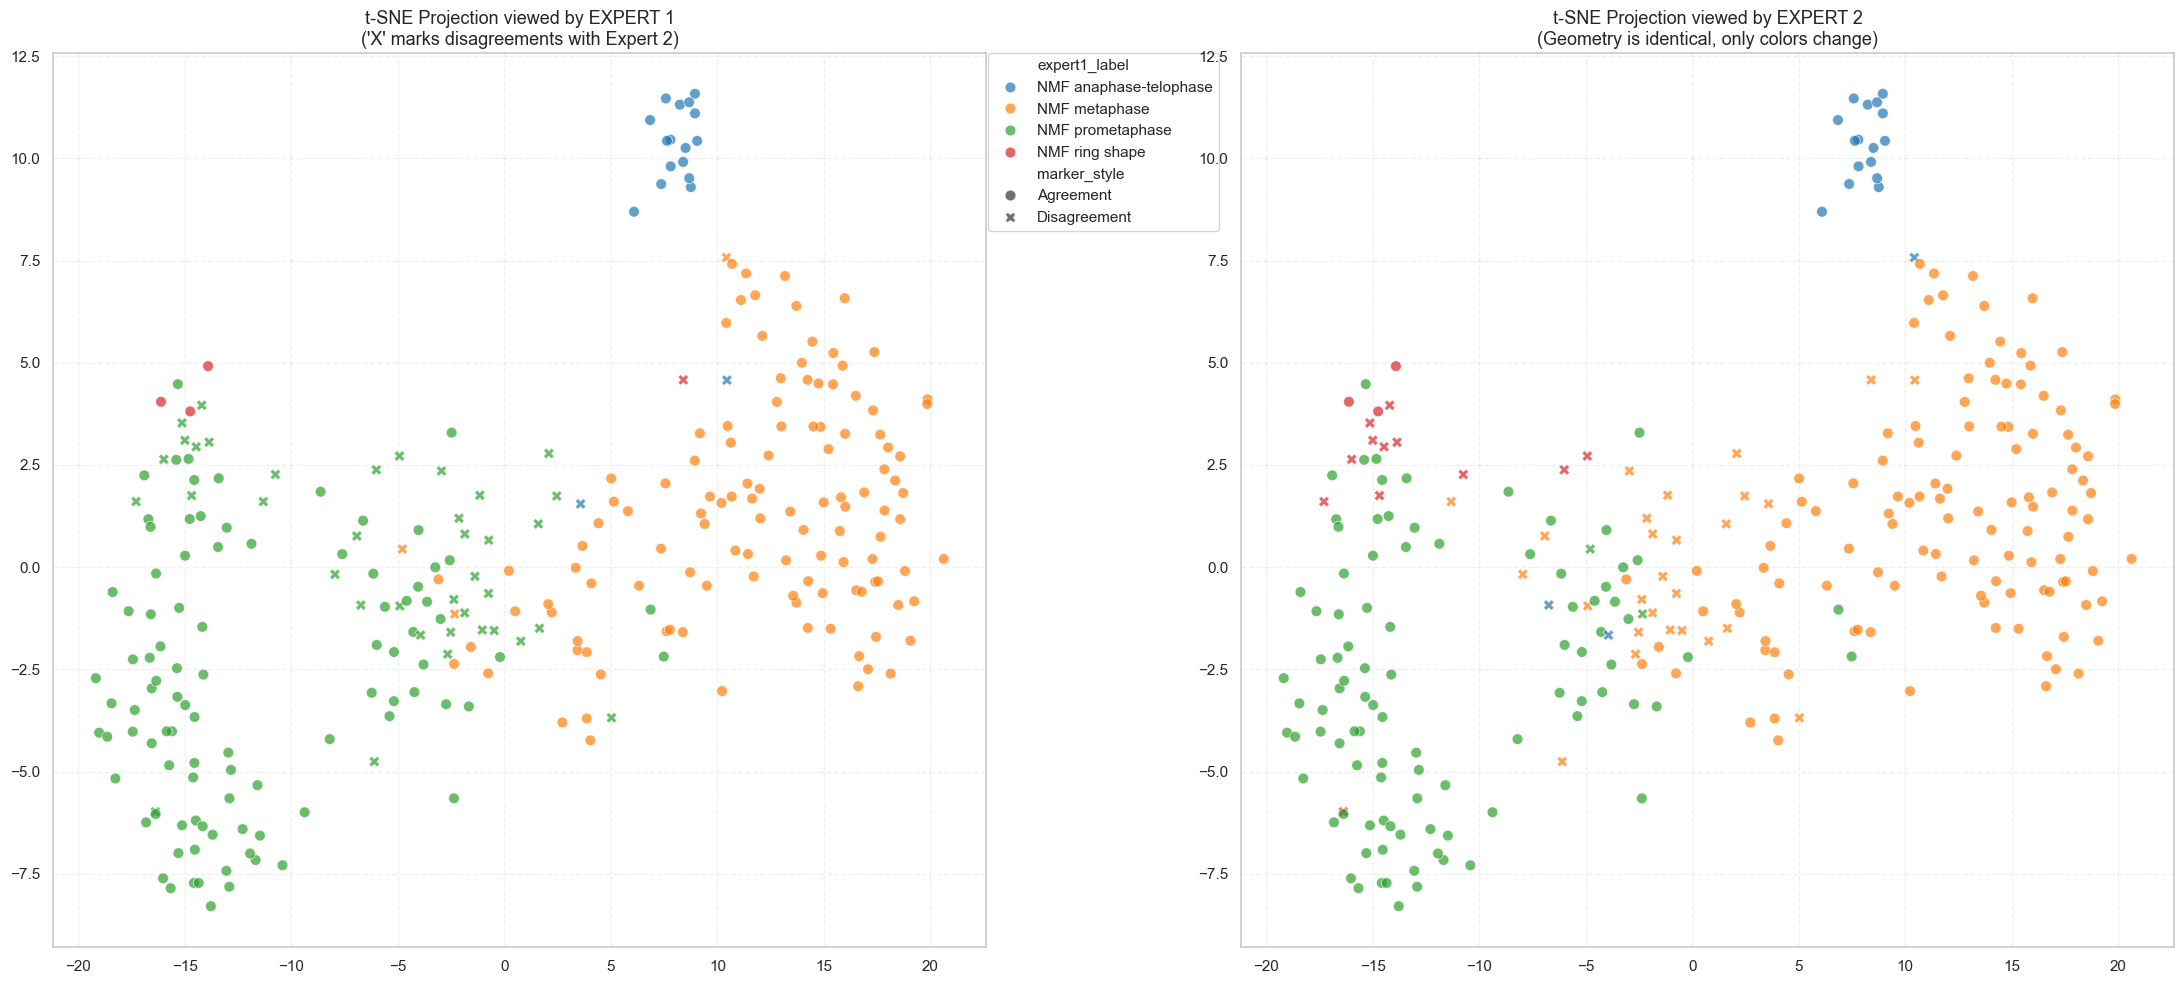

In [45]:
# --- USAGE ---
# Note: use val_loader (shuffle=False) and val_df
visualize_tsne_dual_expert(model_ft, val_loader, val_df, num_samples=2000)

Extracting Upstream AND Downstream features...
Computing Upstream t-SNE (The Eye)...
Computing Downstream t-SNE (The Brain)...


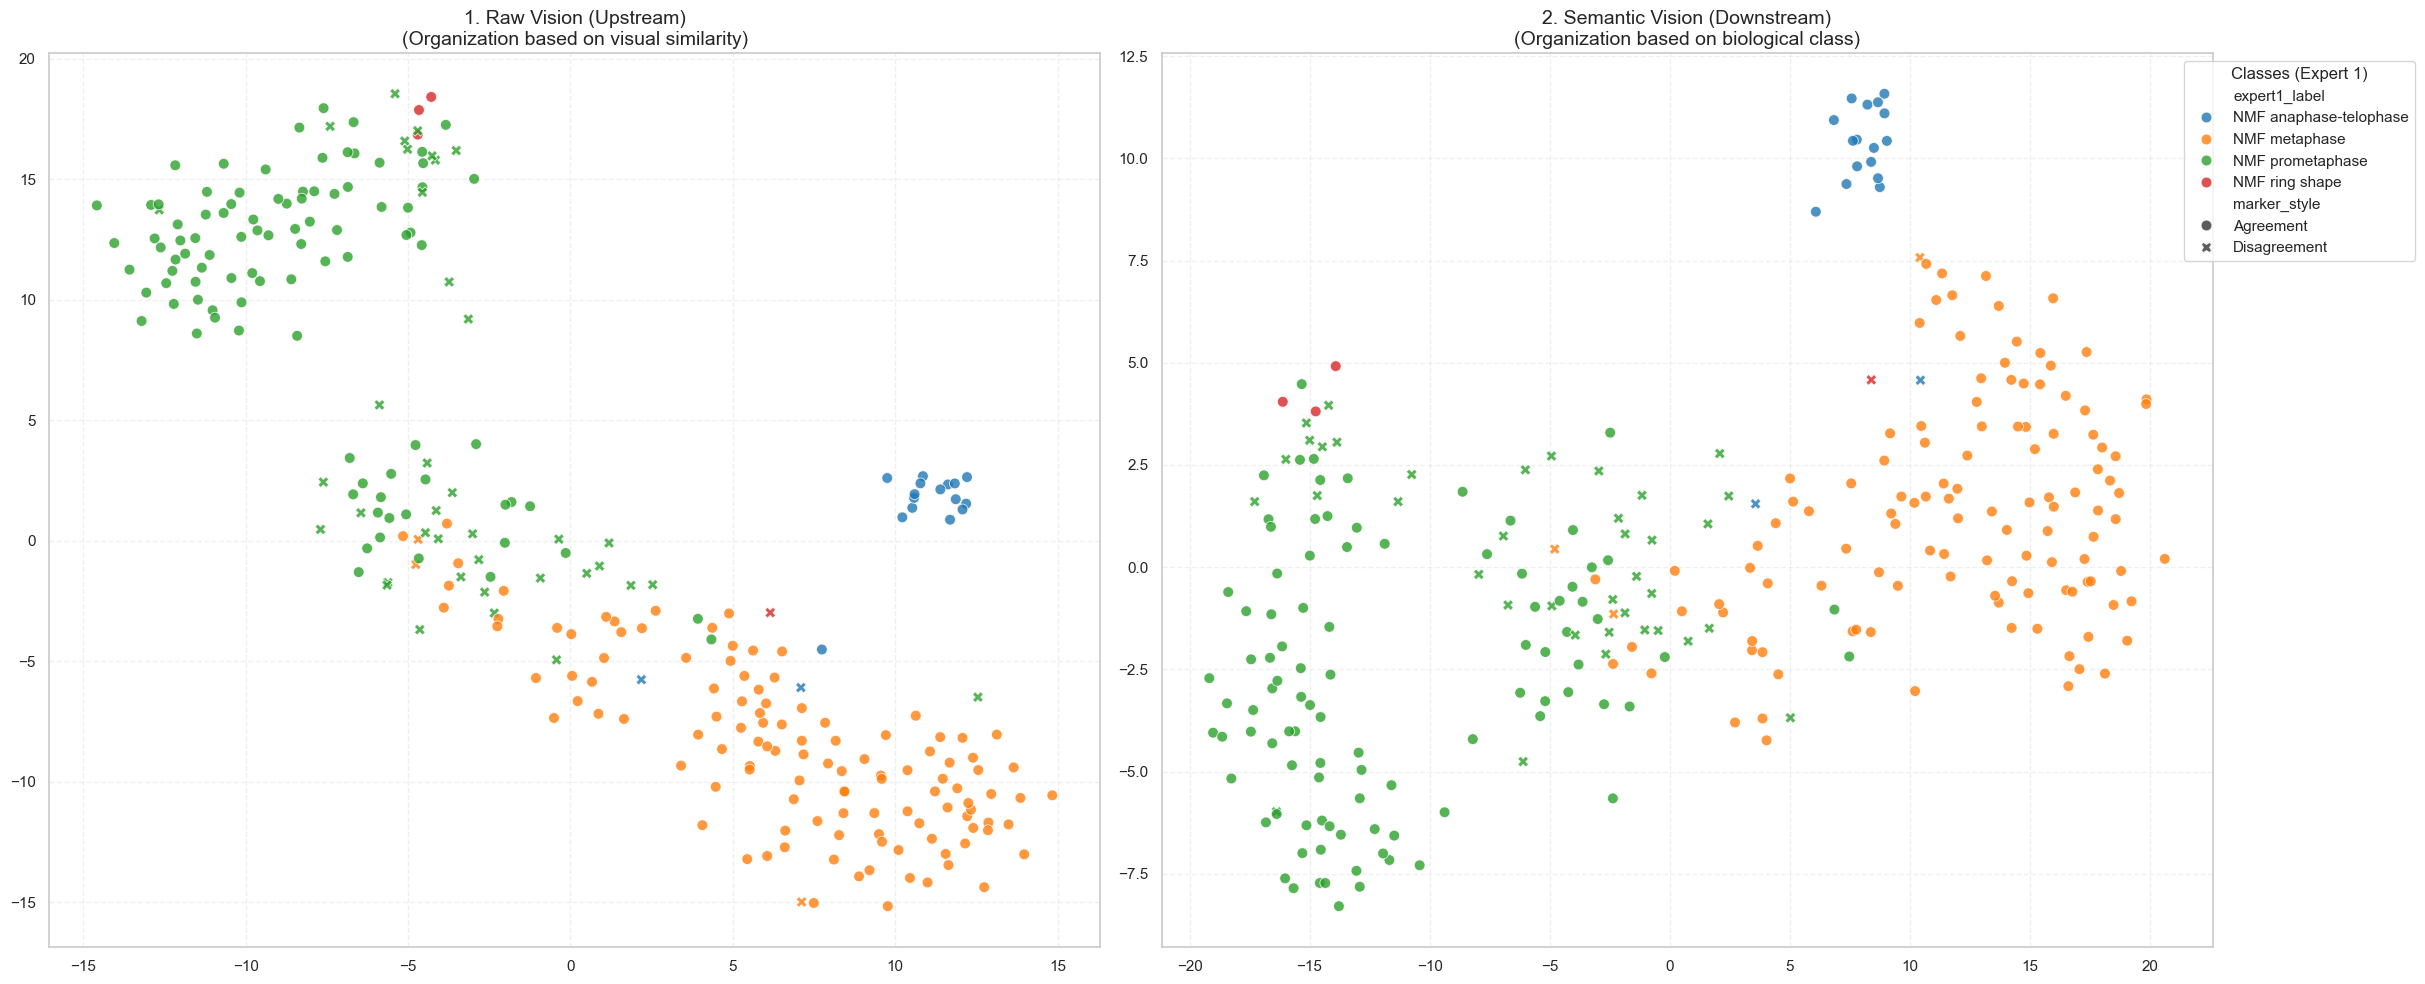

In [46]:
# Usage
visualize_upstream_downstream_comparison(model_ft, val_loader, val_df, num_samples=2000)

Loading pre-trained model (ImageNet)...
--- Loading convnext_tiny model (Mode: feature_extraction) ---
-> Backbone FROZEN (only the head will be trained)
Extracting features...
Calculating t-SNE on 275 points...


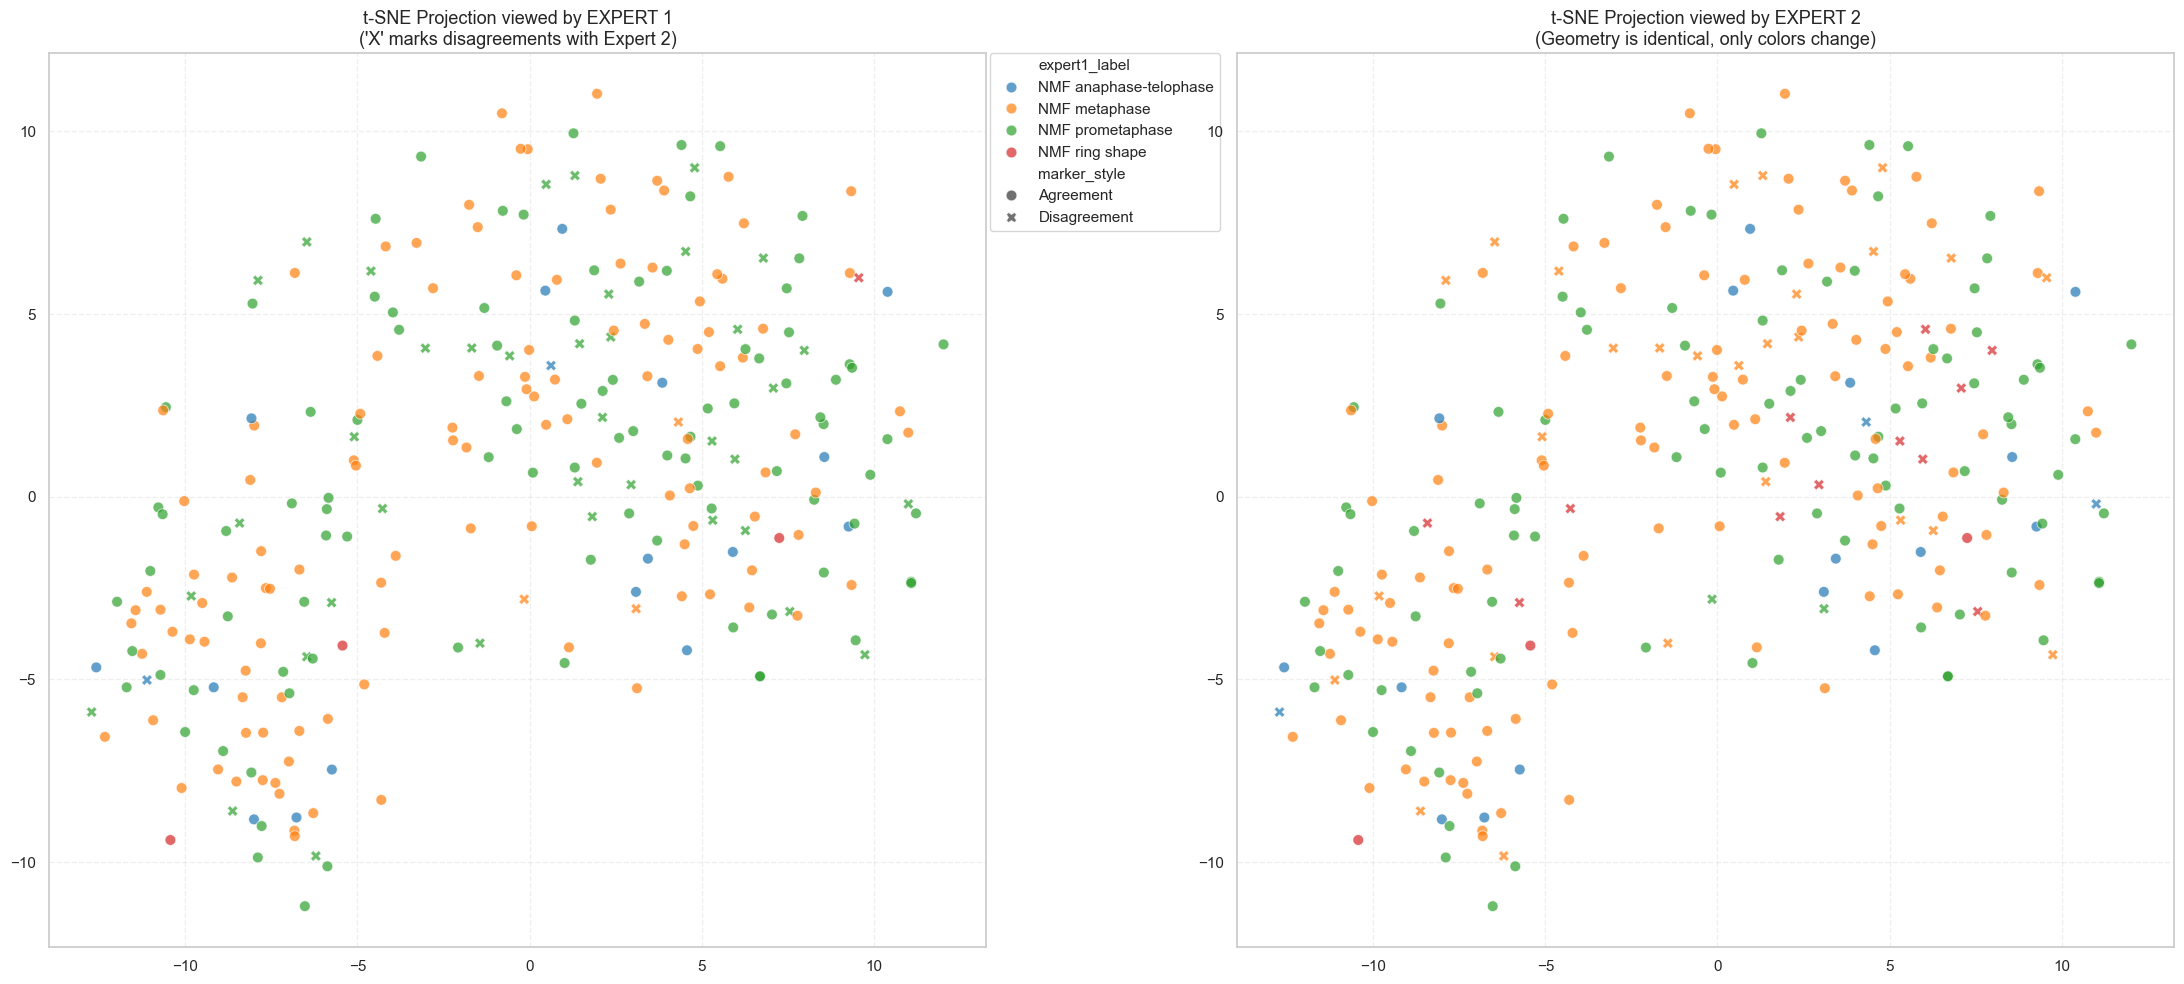

In [47]:
# Load the "Untrained" model (Default ImageNet weights)
# We use 'feature_extraction' mode to load the model without attaching an optimizer.
# This model has never seen your mitosis images.
print("Loading pre-trained model (ImageNet)...")
model_untrained = get_convnext_model(num_classes=len(train_dataset.classes), mode='feature_extraction')
model_untrained = model_untrained.to(CONFIG['DEVICE'])
model_untrained.eval()

# Reuse the existing dual-expert visualization function
visualize_tsne_dual_expert(model_untrained, val_loader, val_df, num_samples=2000)

# Classification activation maps (grad-CAM)

Classification activation maps provide certainly the most popular visualization methods for network inspection.

In [48]:
torch.cuda.empty_cache()

labels_names = train_dataset.classes

Now, we load an image from the `AMI-Br` data base.

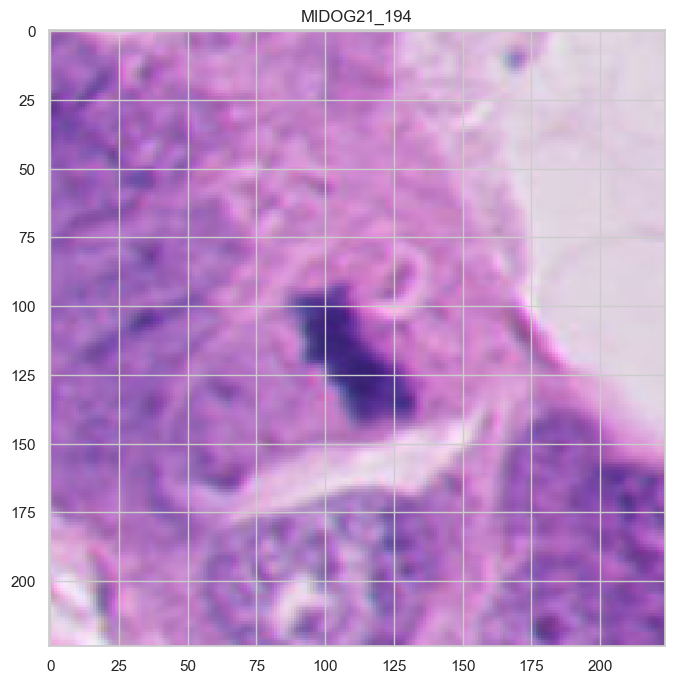

In [49]:
filename = 'MIDOG21_194.png'
folder_name = 'data/patches/normal'

image = Image.open(os.path.join(folder_name, filename)).resize((224, 224))
plt.title('MIDOG21_194')
plt.imshow(image)

Now, we will predict the label of the image.

In [50]:
preprocess = data_transforms['train']

img_prep = preprocess(image)
img_prep = img_prep.unsqueeze(0)

with torch.no_grad():
    img_prediction = model(img_prep.to(CONFIG['DEVICE']))

# Get probabilities by applying softmax to the output
probs = F.softmax(img_prediction, dim=1)

# Convert the probabilities to a numpy array and get the top 3 predictions
top_probs, top_indices = torch.topk(probs, 4, dim=1)
top_probs = top_probs.squeeze().cpu().numpy()
top_indices = top_indices.squeeze().cpu().numpy()

for i in range(3):
    label = labels_names[top_indices[i]]
    print(f"{label} ({top_indices[i]}): {top_probs[i] * 100:.2f}%")

# Get the solution index with the maximum probability
max_index = top_indices[0]
print('Predicted Index:', max_index)

NMF metaphase (1): 99.97%
NMF prometaphase (2): 0.02%
NMF anaphase-telophase (0): 0.01%
Predicted Index: 1


We will use the `Grad-Cam++` implementation from torchcam

 Dataset initialized in [NMF] mode
   -> 2200 images found.
   -> 4 classes : {'NMF anaphase-telophase': 0, 'NMF metaphase': 1, 'NMF prometaphase': 2, 'NMF ring shape': 3}


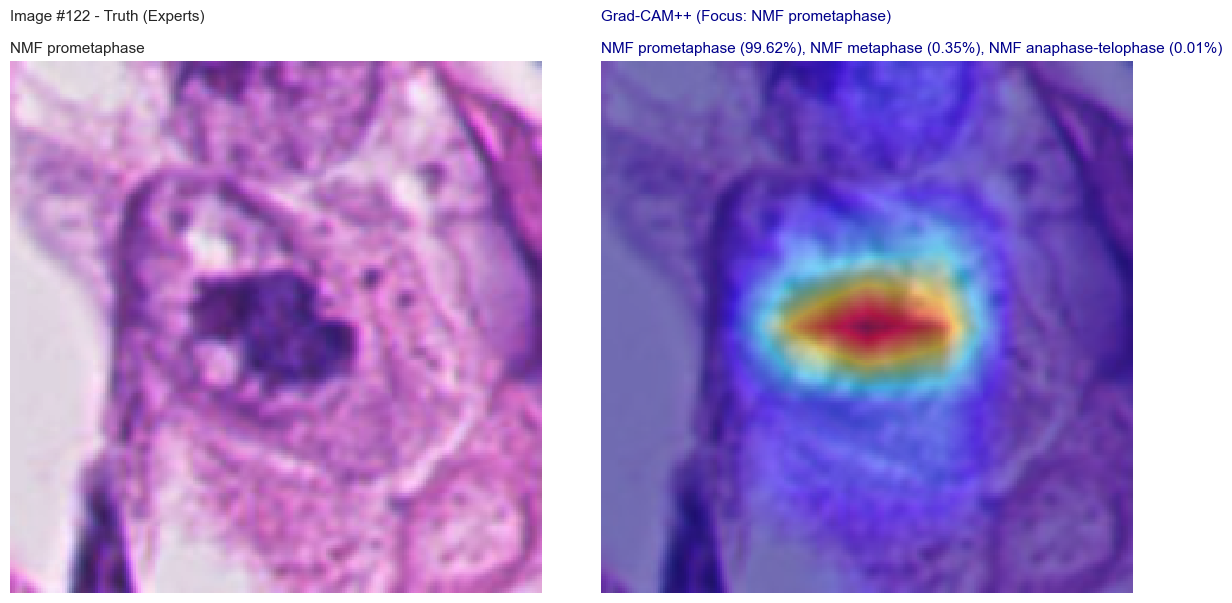

In [51]:
# Immediate test
# Note: I added transform=inference_transforms because the model needs
# normalized tensors to make a correct prediction (and for .unsqueeze to work).
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
vis_dataset = MitosisDataset(
    train_df,
    root_dir=ROOT_DIR,
    transform=inference_transforms
)

# Pick a random image to test
random_idx = random.randint(0, len(vis_dataset)-1)
visualize_explanation_simple(model_ft, vis_dataset, random_idx, device=CONFIG['DEVICE'])

## Probabilistic Confusion Matrix (Soft-Labels)
Standard confusion matrices require integer labels (1 image = 1 class). Our dataset uses probability distributions (e.g., `[0.5 Prophase, 0.5 Metaphase]`).
* **Method:** We compute the matrix product between the *Truth Distribution* and the *Predicted Distribution*.
* **Goal:** Instead of counting "votes," we measure the "probability mass" overlap. This fairly evaluates the model on ambiguous samples without forcing a binary decision.

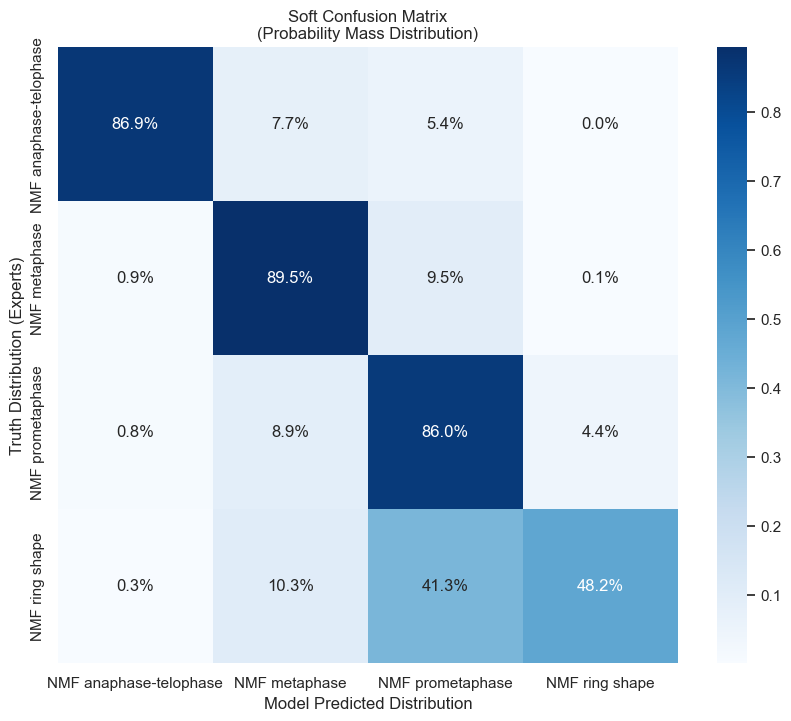

In [52]:
# Usage
plot_soft_confusion_matrix(model_ft, val_loader, CONFIG['DEVICE'], train_dataset.classes)

## Uncertainty Calibration (Group Analysis)
We split the test set into two groups to verify if the model has learned to identify ambiguity:
* **Group A (Consensus):** Experts agree. The model should be **Confident** (High Probability).
* **Group B (Disagreement):** Experts disagree. The model should be **Uncertain** (Lower Probability, spread across classes).
* **Visual:** We use Kernel Density Estimation (KDE) plots to visualize the shift in confidence between these two groups.

Group analysis in progress...

Distribution: 231 Agreement cases (A) / 44 Disagreement cases (B)

✅ GROUP A (Consensus) - Accuracy : 96.97%
   -> Average Model Confidence : 95.2%

⚠️ GROUP B (Disagreement) - Double Coverage Accuracy : 79.55%
   (The model's Top-2 predictions capture BOTH experts)
   -> Average Model Confidence : 75.0%


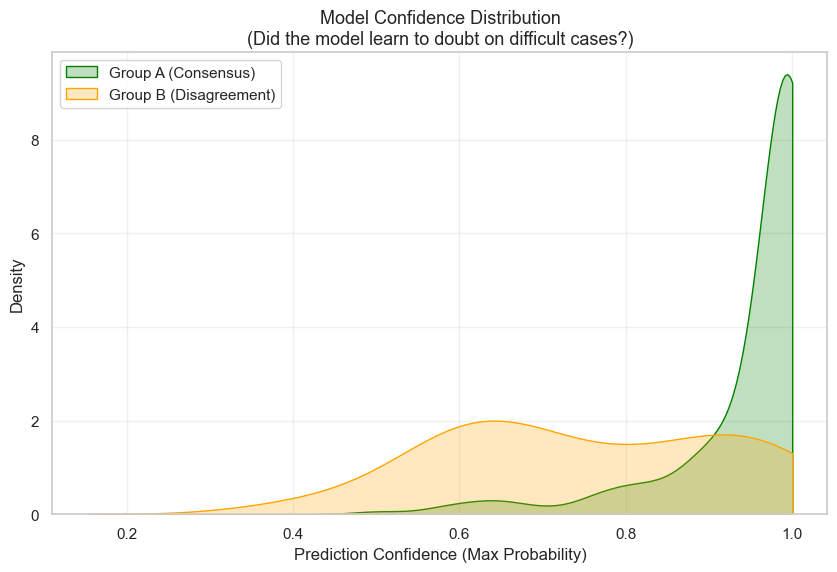

In [54]:
# --- USAGE ---
evaluate_by_groups(model_ft, val_loader, val_df, CONFIG['DEVICE'])

## Latent Space Geometry (t-SNE)
Finally, we project the model's high-dimensional features into 2D space to check the structural consistency.
* **Color Code:** 🔴 **Red** (Low Confidence) $\to$ 🟢 **Green** (High Confidence).
* **Markers:** `Circles` (Consensus) vs. `Crosses` (Disagreement).
* **Hypothesis:** We expect "Red Crosses" (uncertain disagreements) to be located naturally at the **boundaries between clusters**, reflecting the semantic transition between mitotic phases.

Extracting features & confidence for t-SNE (Max samples: 2000)...
Computing t-SNE (this may take a moment)...


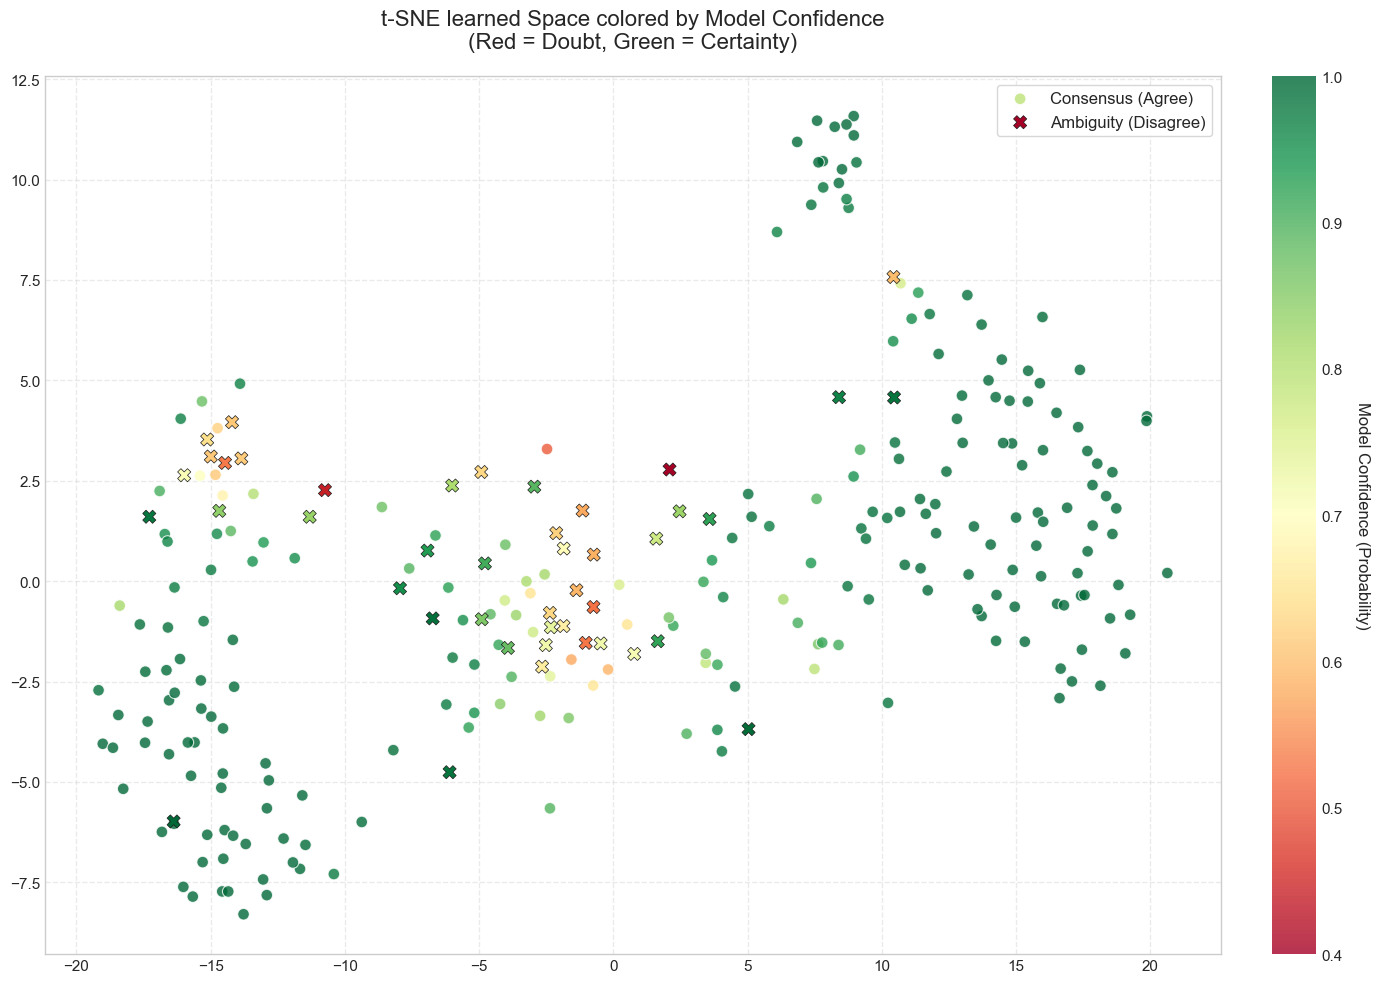

In [55]:
# Usage
visualize_confidence_tsne(model_ft, val_loader, val_df, CONFIG['DEVICE'], num_samples=2000)

# Evaluation Strategy: Beyond Global Accuracy

A simple accuracy metric is misleading when the ground truth itself is subjective. We implemented a **full test battery** that agregates everything we saw before :

Failed to read module file 'c:\Users\elyes\Bash\r_sante\src\visualization.py' for module 'src.visualization': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\elyes\Bash\r_sante\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 556, in maybe_reload_module
    new_source_code = f.read()
  File "C:\miniconda\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 10924: character maps to <undefined>
Failed to read module file 'c:\Users\elyes\Bash\r_sante\src\evaluation.py' for module 'src.evaluation': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\elyes\Bash\r_sante\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 556, in maybe_reload_module
    new_source_code = f.read()
  File "C:\mini

📢 Launching full test battery on TEST SET...
✅ 'best_model.pth' weights loaded successfully.

1️⃣ COMPARISON WITH EXPERTS (Matrices)
Generating model predictions...

🔍 RESULTS vs EXPERT 1
                        precision    recall  f1-score   support

NMF anaphase-telophase       1.00      0.89      0.94        19
         NMF metaphase       0.90      0.98      0.94       119
      NMF prometaphase       0.97      0.89      0.93       133
        NMF ring shape       0.40      0.50      0.44         4

              accuracy                           0.93       275
             macro avg       0.82      0.82      0.81       275
          weighted avg       0.93      0.93      0.93       275


🔍 RESULTS vs EXPERT 2
                        precision    recall  f1-score   support

NMF anaphase-telophase       0.94      0.84      0.89        19
         NMF metaphase       0.98      0.86      0.92       148
      NMF prometaphase       0.74      0.97      0.84        94
        NMF ring 

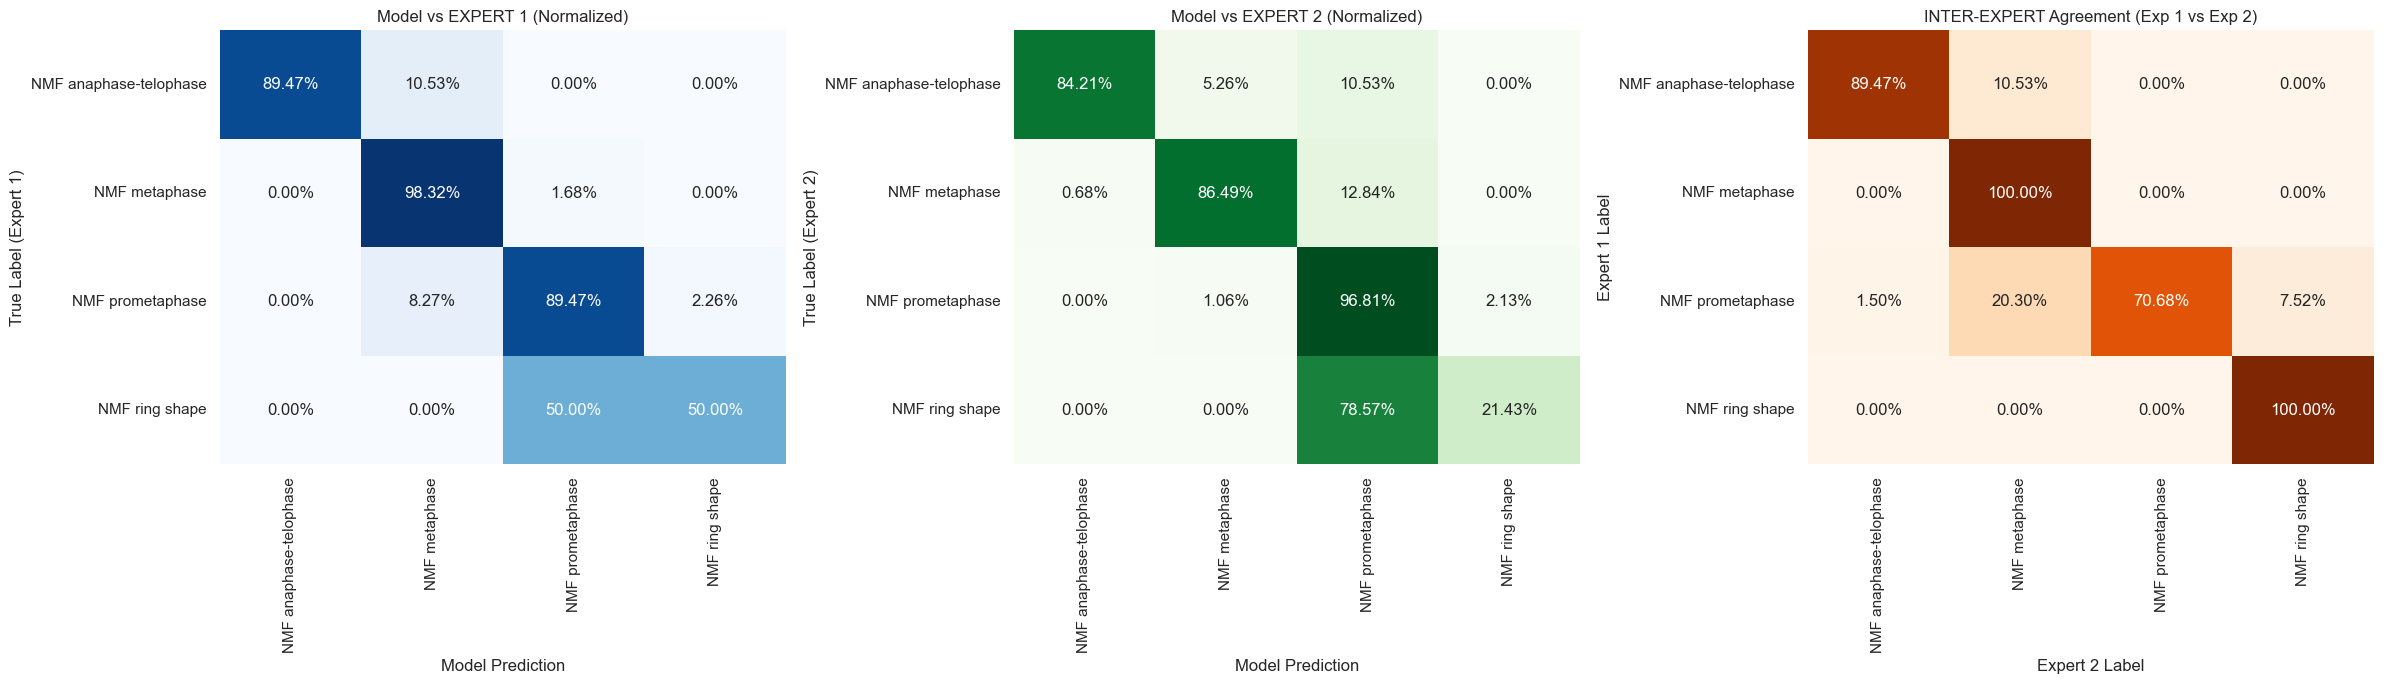


2️⃣ TOP-2 INDULGENT CONFUSION MATRICES
Generating Top-2 predictions...


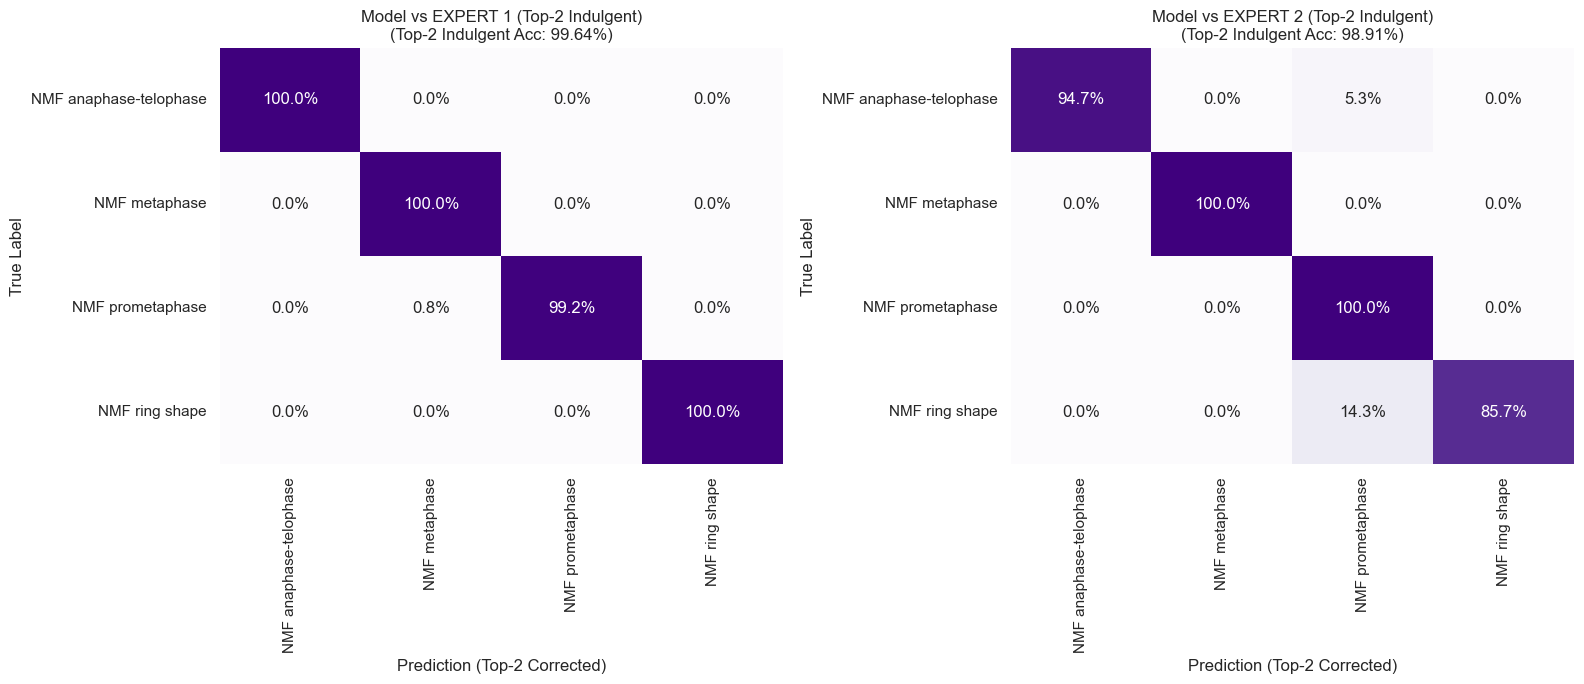


3️⃣ GROUP PERFORMANCE (Agreement/Disagreement)
Group analysis in progress...

Distribution: 234 Agreement cases (A) / 41 Disagreement cases (B)

✅ GROUP A (Consensus) - Accuracy : 96.58%
   -> Average Model Confidence : 95.4%

⚠️ GROUP B (Disagreement) - Double Coverage Accuracy : 90.24%
   (The model's Top-2 predictions capture BOTH experts)
   -> Average Model Confidence : 79.9%


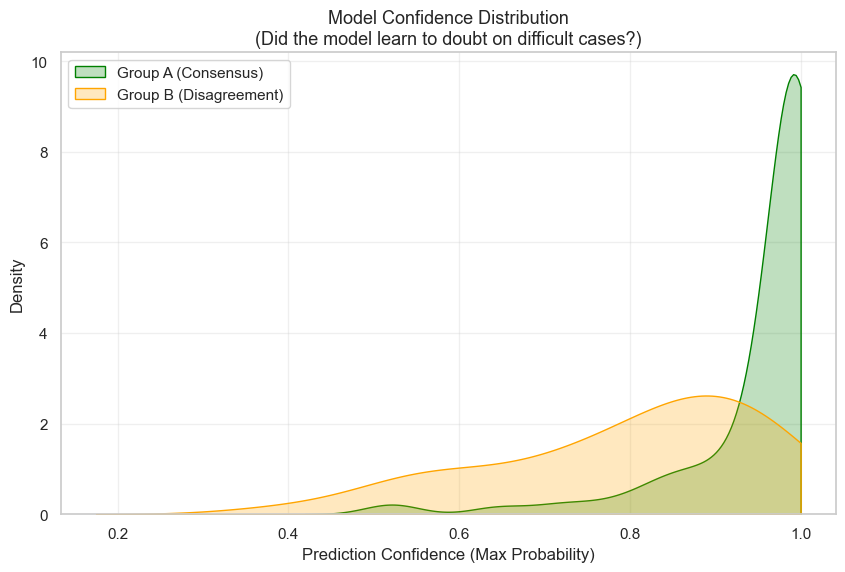


4️⃣ PROBABILISTIC CONFUSION MATRIX


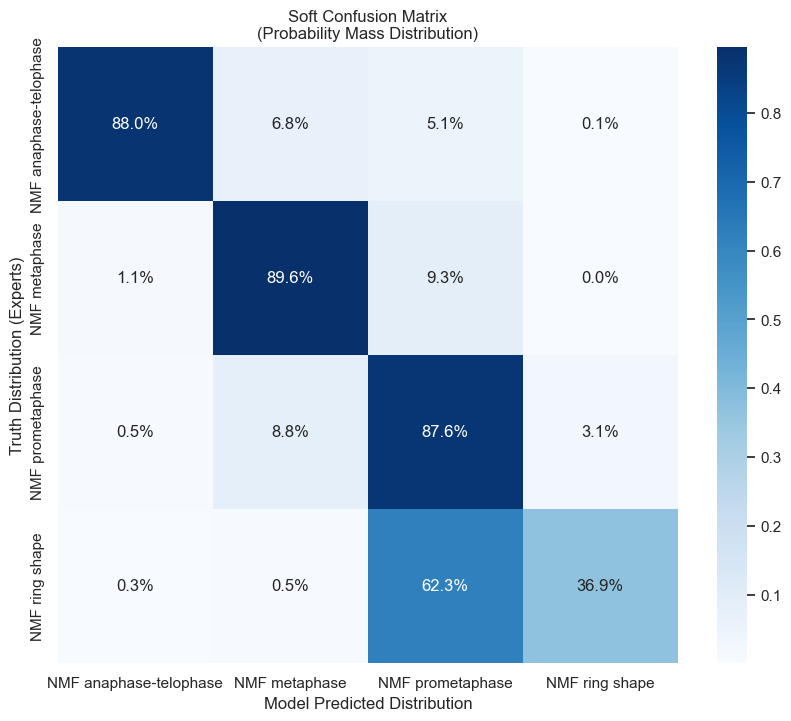


5️⃣ t-SNE: SPACE REPRESENTATION
Extracting features...
Calculating t-SNE on 275 points...


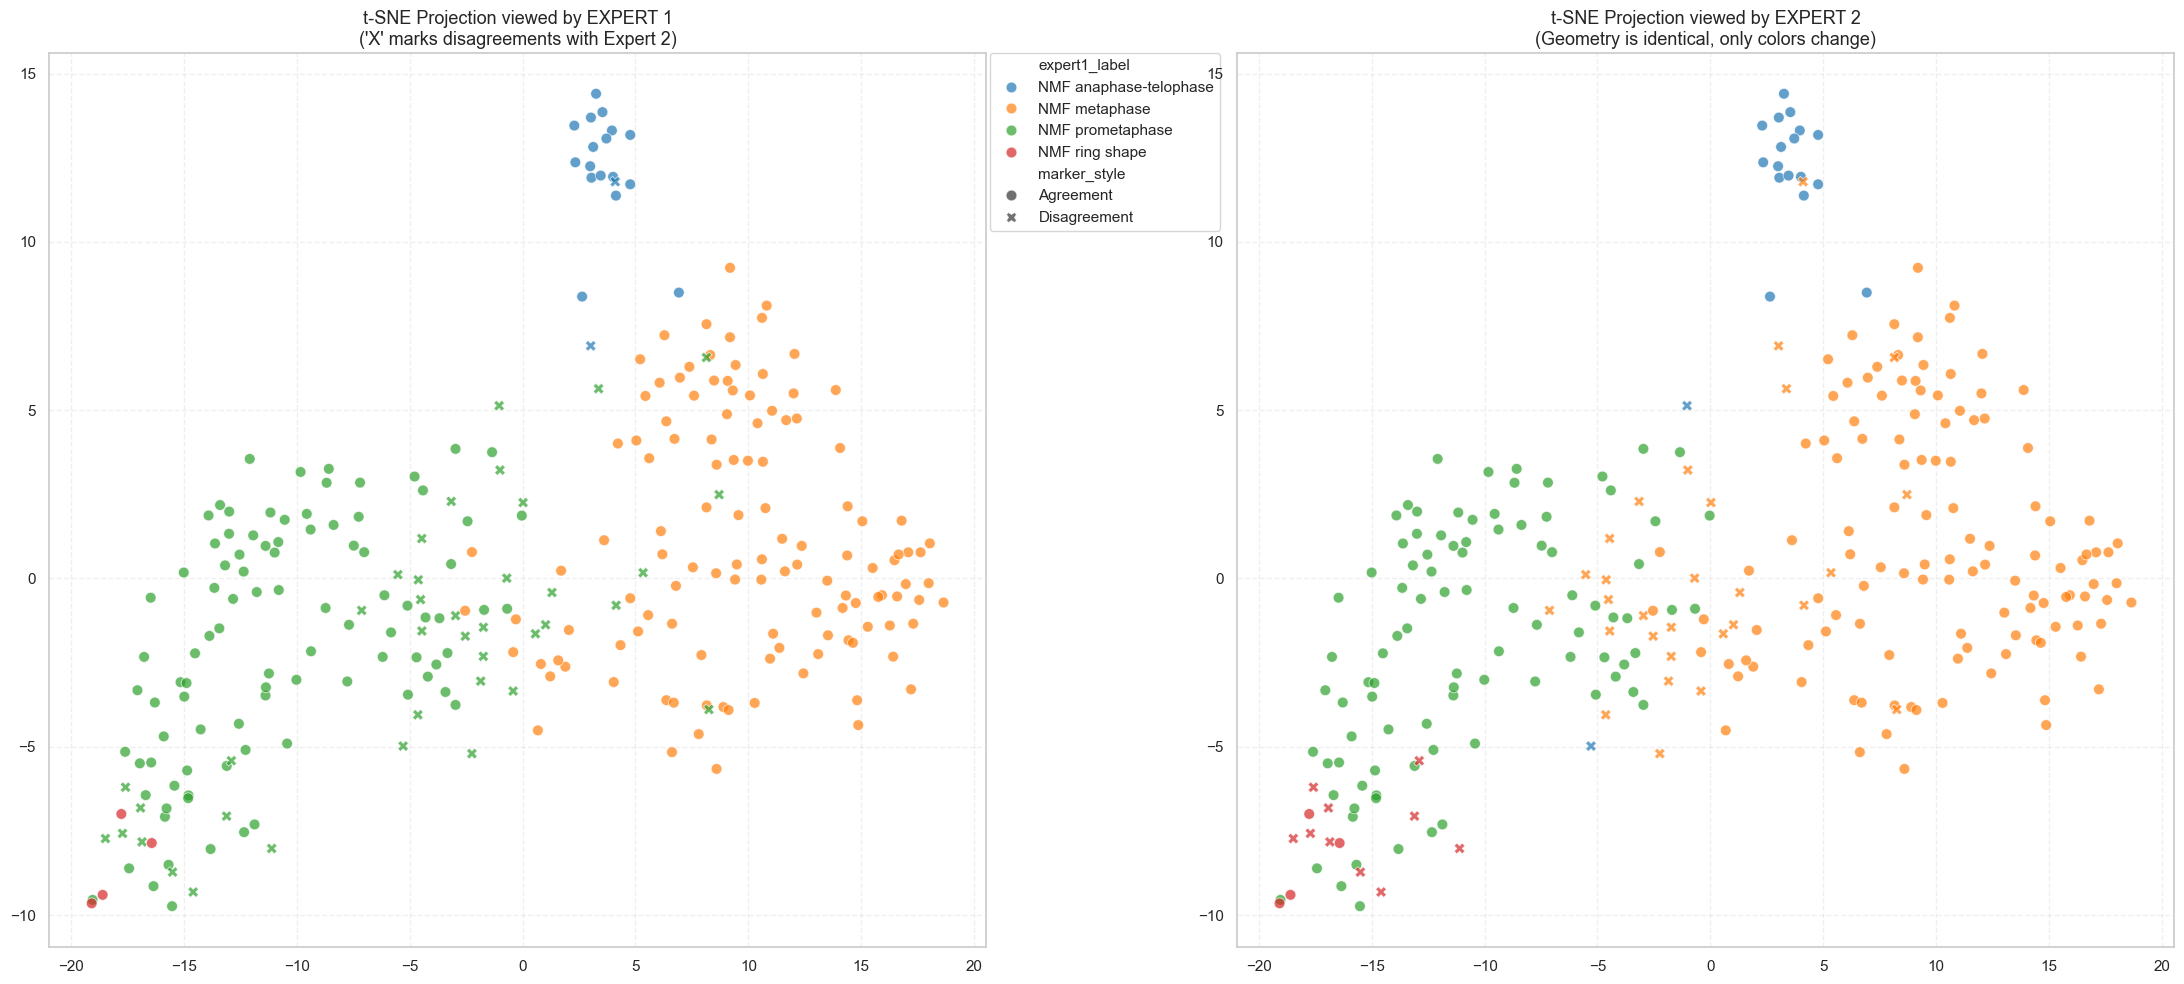


6️⃣ t-SNE: 'EYE' VISION (Features) vs 'BRAIN' (Classifier)
Extracting Upstream AND Downstream features...
Computing Upstream t-SNE (The Eye)...
Computing Downstream t-SNE (The Brain)...


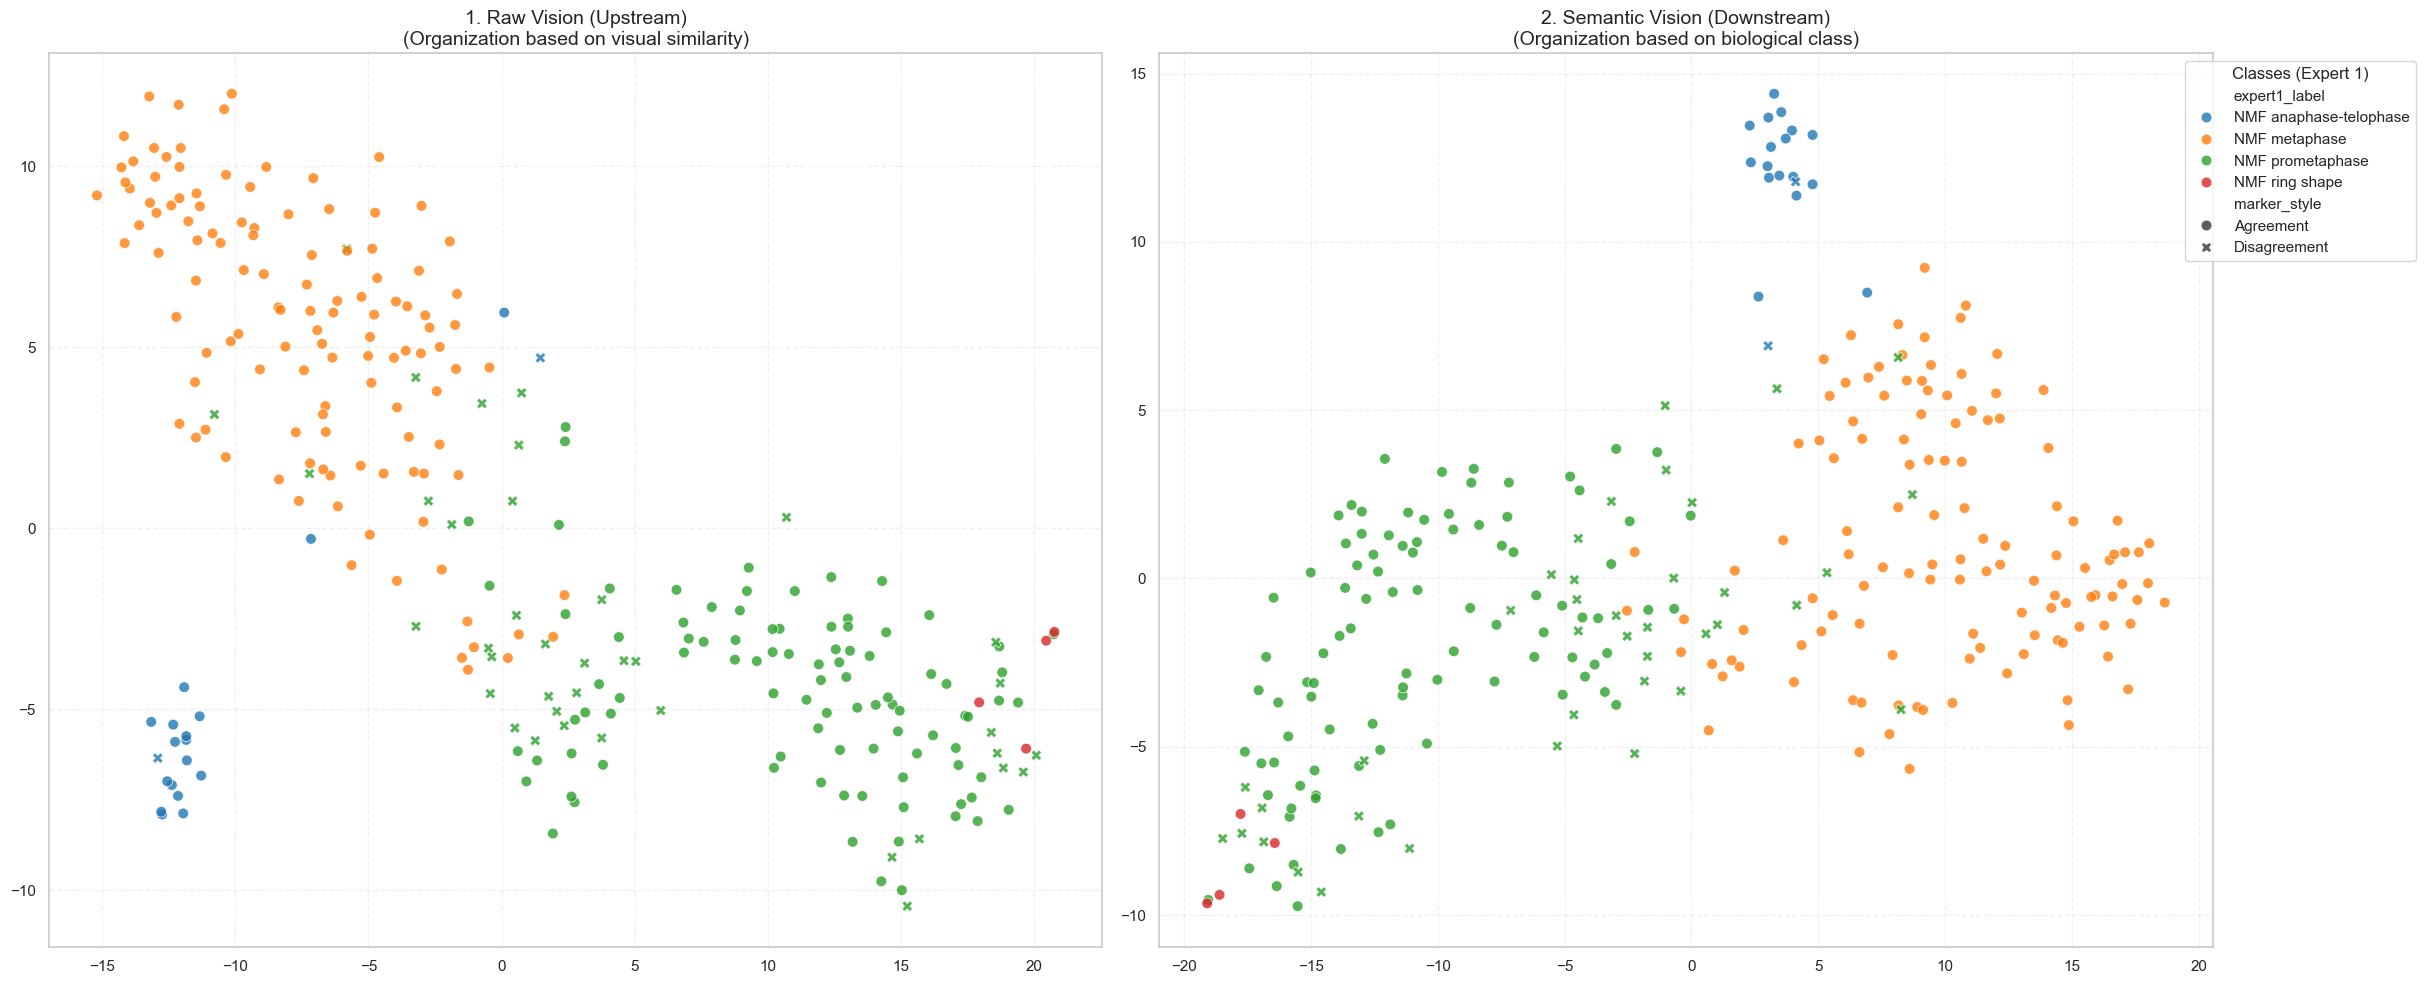


7️⃣ t-SNE: CONFIDENCE LANDSCAPE
Extracting features & confidence for t-SNE (Max samples: 2000)...
Computing t-SNE (this may take a moment)...


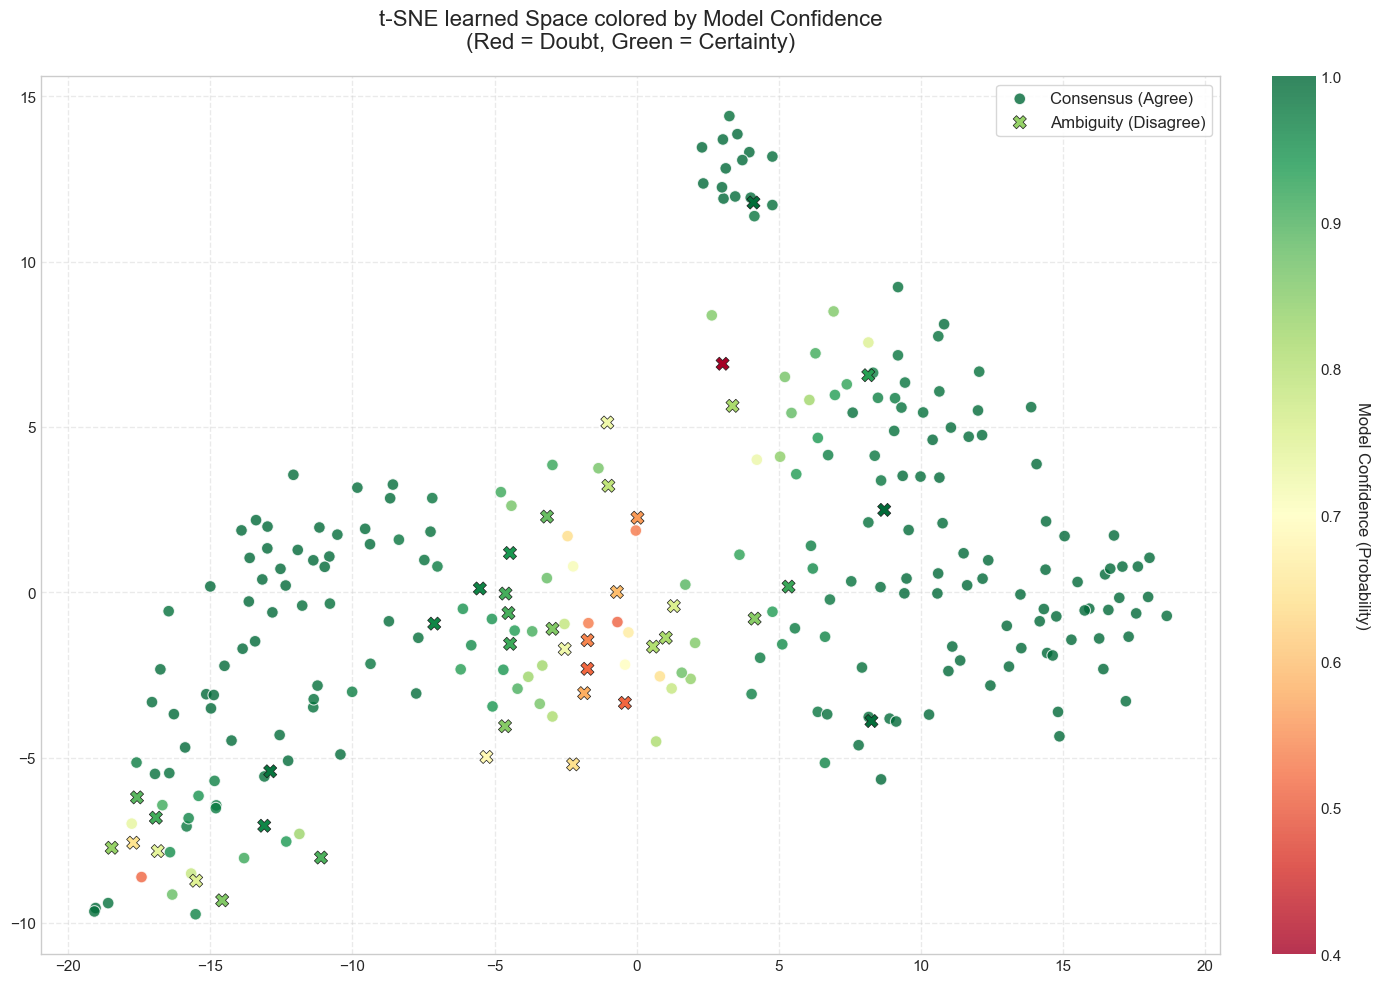


8️⃣ GRAD-CAM: RANDOM EXAMPLES FROM TEST SET
--- Explainability for Test image index 47 ---


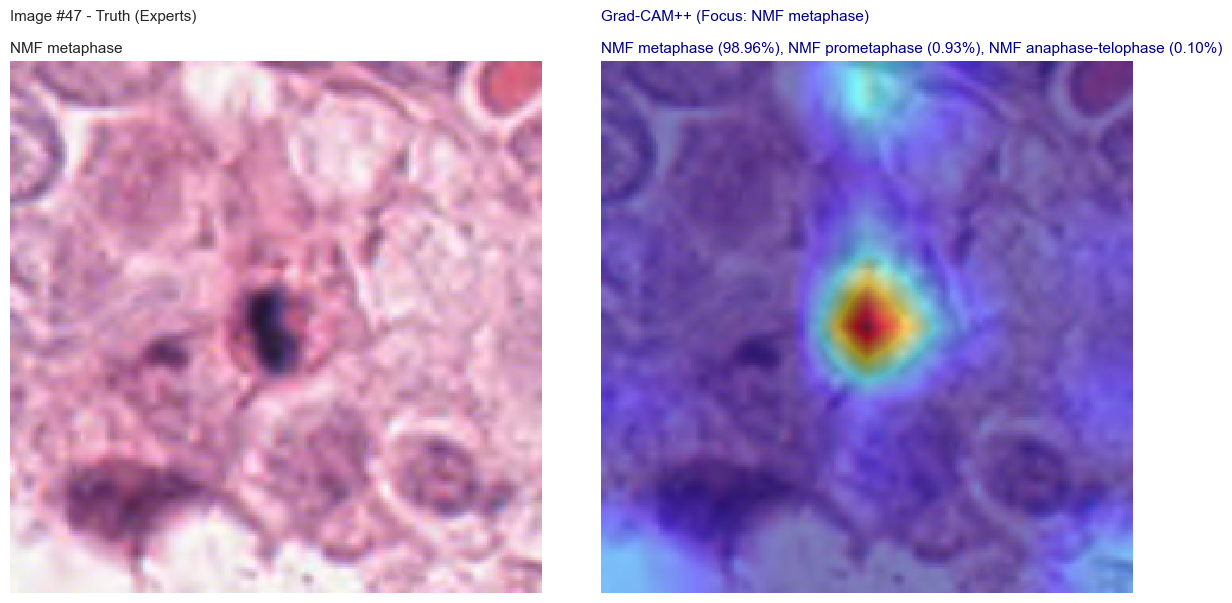

--- Explainability for Test image index 111 ---


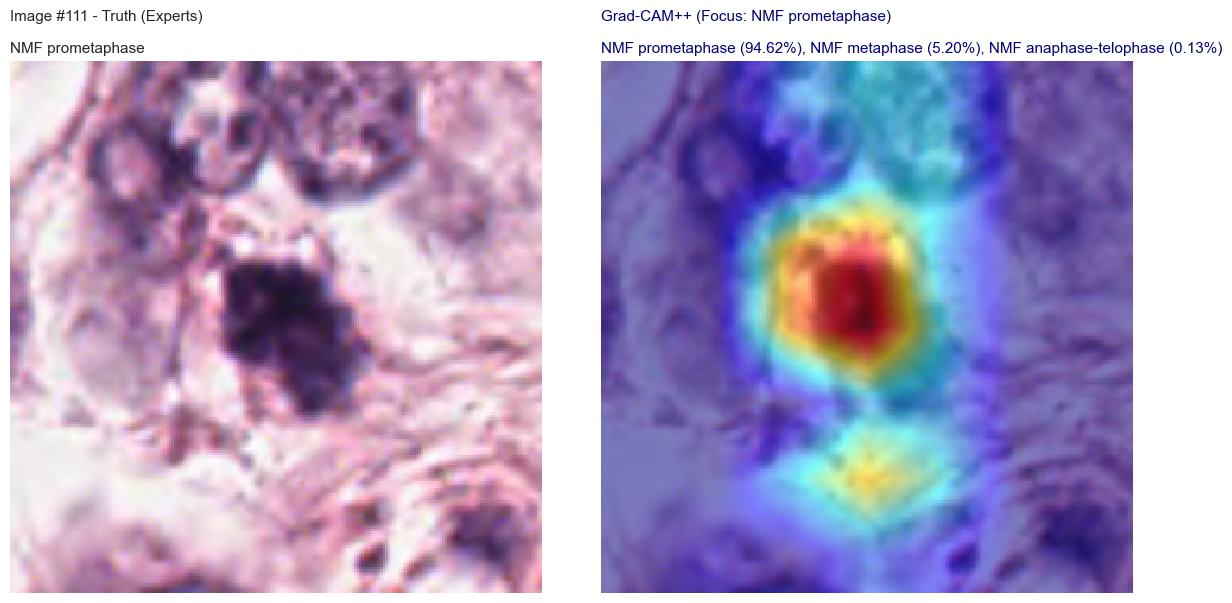

--- Explainability for Test image index 119 ---


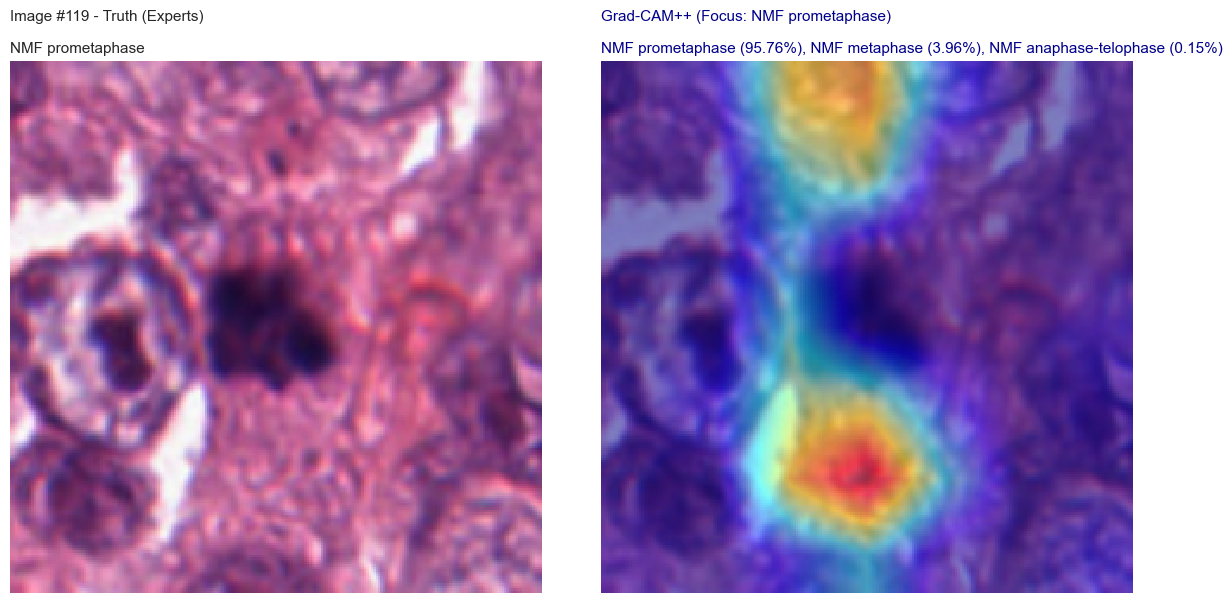

In [57]:
run_full_test_battery(model_ft, dataloaders, test_df, train_dataset.classes, CONFIG['DEVICE'])

## Conclusion

Our Soft-Label approach successfully demonstrates that Deep Learning can handle medical uncertainty:

1.  **Performance:** The model reaches the **Human Baseline (~70%)** on strict accuracy.
2.  **Calibration:** The **KDE plots** show that the model is highly confident on consensus cases (Group A) and appropriately uncertain on ambiguous cases (Group B).
3.  **Explainability:** The **t-SNE** projection confirms that "errors" are logically located at the semantic boundaries of the mitotic phases.

**Final Verdict:** The model does not just classify; it qualifies its decision, providing a safety net for clinical implementation.